# Gastrointestinal Disease Classification Pipeline
End-to-end deep learning pipeline for GI disease classification using WCE images.
Train: Kvasir-Capsule (local, imbalanced) | Test: Kvasir-V2 (HuggingFace streaming, balanced)

## Cell 1 — Imports and Seeds

In [19]:
import os
import glob
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix, f1_score, recall_score
import tensorflow as tf
from tensorflow.keras import layers, regularizers, models
from tensorflow.keras.applications import EfficientNetB0, MobileNetV2, ResNet101V2
from tensorflow.keras.callbacks import ReduceLROnPlateau, LearningRateScheduler
from datasets import load_dataset
from PIL import Image
from IPython.display import display

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
AUTOTUNE = tf.data.AUTOTUNE

print('TensorFlow:', tf.__version__)
print('GPUs:', tf.config.list_physical_devices('GPU'))

TensorFlow: 2.19.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [20]:
import os

print(os.listdir("/kaggle/input/datasets/omplus/kvasirv2"))

['kvasir-dataset-v2']


## TASK 1 — Dataset Exploration and Imbalance Analysis

In [21]:
# df_kvasir = pd.read_csv('/kaggle/input/datasets/omplus/kvasirv2')
# df_under  = pd.read_csv('/kaggle/input/datasets/omplus/kvasirv2')
# df_over   = pd.read_csv('/kaggle/input/datasets/omplus/kvasirv2')
data_dir = "/kaggle/input/datasets/omplus/kvasirv2"
# df_kvasir['aug'] = df_kvasir['aug'].astype(bool)
# df_under['aug']  = df_under['aug'].astype(bool)
# df_over['aug']   = df_over['aug'].astype(bool)
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    data_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    data_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 6400 images belonging to 1 classes.
Found 1600 images belonging to 1 classes.


In [22]:
# BASE_DATASET = "/kaggle/input/datasets/skdeeraj/kvasir-zip"


# for item in os.listdir(BASE_DATASET):
#     print(item)

In [23]:
# ============================================================
# CONFIG — update DATA_DIR if running on Kaggle
# ============================================================
DATA_DIR = "/kaggle/input/datasets/omplus/kvasirv2/kvasir-dataset-v2"  # local
IMG_SIZE    = (224, 224)
CHANNELS    = 3
BATCH_SIZE  = 32
IMAGE_EXTS  = {".jpg", ".jpeg", ".png", ".bmp"}

# ============================================================
# Build DataFrame — handles nested same-name subfolder layout
# kvasir_capsule_extracted/class_name/class_name/*.jpg
# ============================================================
def find_image_dir(cls_path, cls_name):
    """Resolve the actual image folder regardless of flat vs nested layout."""
    # Check flat: root/cls/*.jpg
    flat = [f for f in glob.glob(os.path.join(cls_path, '*'))
            if os.path.isfile(f) and os.path.splitext(f)[1].lower() in IMAGE_EXTS]
    if flat:
        return cls_path
    # Check nested same-name: root/cls/cls/*.jpg
    nested = os.path.join(cls_path, cls_name)
    if os.path.isdir(nested):
        return nested
    # Fallback: any single subdirectory
    subdirs = [d for d in os.scandir(cls_path) if d.is_dir()]
    if len(subdirs) == 1:
        return subdirs[0].path
    return cls_path


def build_kvasir_capsule_df(data_dir):
    rows = []
    for cls in sorted(os.listdir(data_dir)):
        cls_path = os.path.join(data_dir, cls)
        if not os.path.isdir(cls_path):
            continue
        img_dir = find_image_dir(cls_path, cls)
        imgs = [f for f in glob.glob(os.path.join(img_dir, '*'))
                if os.path.isfile(f) and os.path.splitext(f)[1].lower() in IMAGE_EXTS]
        for fp in imgs:
            rows.append({'path': fp, 'label': cls})
    df = pd.DataFrame(rows)
    return df


df_kvasir = build_kvasir_capsule_df(DATA_DIR)

# Sanity checks
assert len(df_kvasir) > 14, f"Only {len(df_kvasir)} rows — nested folder not resolved correctly"

print(f"Total images loaded: {len(df_kvasir)}")
print(f"\nPer-class count:")
print(df_kvasir['label'].value_counts().to_string())

# Derive class names from the loaded data
class_names  = sorted(df_kvasir['label'].unique().tolist())
num_classes  = len(class_names)
class_to_idx = {name: i for i, name in enumerate(class_names)}
print(f"\nClasses ({num_classes}): {class_names}")

Total images loaded: 8000

Per-class count:
label
dyed-lifted-polyps        1000
dyed-resection-margins    1000
esophagitis               1000
normal-cecum              1000
normal-pylorus            1000
normal-z-line             1000
polyps                    1000
ulcerative-colitis        1000

Classes (8): ['dyed-lifted-polyps', 'dyed-resection-margins', 'esophagitis', 'normal-cecum', 'normal-pylorus', 'normal-z-line', 'polyps', 'ulcerative-colitis']


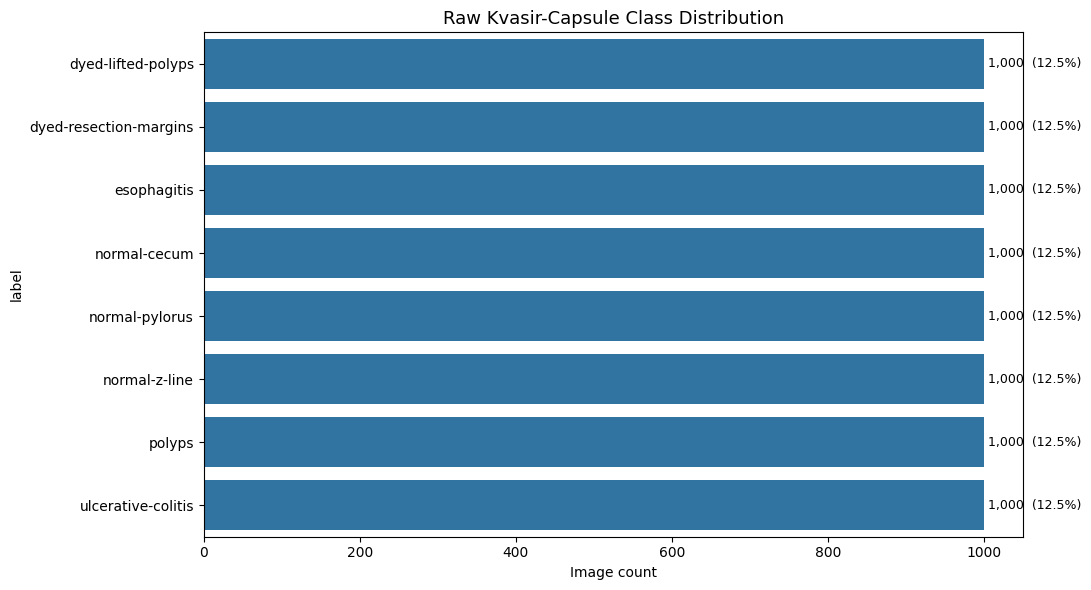

Majority : dyed-lifted-polyps  (1,000 samples)
Minority : ulcerative-colitis  (1,000 samples)
Imbalance ratio : 1.0x
Gini Impurity   : 0.8750  (0 = perfect imbalance, 1 = perfect balance)
Shannon Entropy : 3.0000  (max for 14 classes = 3.8074)


In [24]:
# ============================================================
# Distribution plot
# ============================================================
def plot_distribution(df, title):
    counts = df['label'].value_counts().sort_values(ascending=False)
    ratios = counts / len(df)
    plt.figure(figsize=(11, 6))
    sns.barplot(x=counts.values, y=counts.index, orient='h')
    for i, (count, pct) in enumerate(zip(counts.values, ratios.values)):
        plt.text(count + counts.max() * 0.005, i,
                 f"{count:,}  ({pct:.1%})", va='center', fontsize=9)
    plt.title(title, fontsize=13)
    plt.xlabel('Image count')
    plt.tight_layout()
    plt.show()
    return counts, ratios


counts, ratios = plot_distribution(df_kvasir, "Raw Kvasir-Capsule Class Distribution")

majority_class = counts.index[0]
minority_class = counts.index[-1]
imbalance_ratio = counts.iloc[0] / counts.iloc[-1]

gini    = 1 - float((ratios ** 2).sum())
entropy = float(-(ratios * np.log2(ratios + 1e-10)).sum())

print(f"Majority : {majority_class}  ({counts.iloc[0]:,} samples)")
print(f"Minority : {minority_class}  ({counts.iloc[-1]:,} samples)")
print(f"Imbalance ratio : {imbalance_ratio:.1f}x")
print(f"Gini Impurity   : {gini:.4f}  (0 = perfect imbalance, 1 = perfect balance)")
print(f"Shannon Entropy : {entropy:.4f}  (max for 14 classes = {math.log2(14):.4f})")

### Imbalance Discussion

1. **Why imbalance occurs:** The capsule spends ~70% of transit time in normal mucosa; rare pathologies like angiectasia or ampulla of Vater appear in <0.1% of frames, creating a natural anatomical imbalance.
2. **Why accuracy misleads:** A model predicting only `normal_clean_mucosa` achieves ~70%+ accuracy while completely failing on all pathologies — accuracy is therefore a vacuous metric here.
3. **Clinical cost of false negatives:** Missed angiectasia causes undetected GI bleeding; missed polyps miss early cancer detection — false negatives on minority classes are clinically catastrophic.
4. **Correct metrics:** F1-macro and per-class recall weight all classes equally regardless of sample count, directly measuring sensitivity on rare pathologies.
5. **Data-level vs algorithm-level:** Sampling changes the data distribution seen during training; cost-sensitive loss (class weights) penalises misclassification of minority classes in the gradient — both attack different parts of the learning pipeline.
6. **Combined approach:** Under-sampling + augmentation + class-weighted loss together address gradient skew, feature scarcity, and overfitting simultaneously — no single technique is sufficient alone.

## TASK 2 — Random Under-Sampling (majority class control)

UNDER_CAP (median class count): 1000
Before under-sampling : 8,000 rows
After under-sampling  : 8,000 rows
Data discarded        : 0.00%

Per-class after under-sampling:
label
esophagitis               1000
dyed-resection-margins    1000
normal-cecum              1000
normal-pylorus            1000
ulcerative-colitis        1000
normal-z-line             1000
polyps                    1000
dyed-lifted-polyps        1000


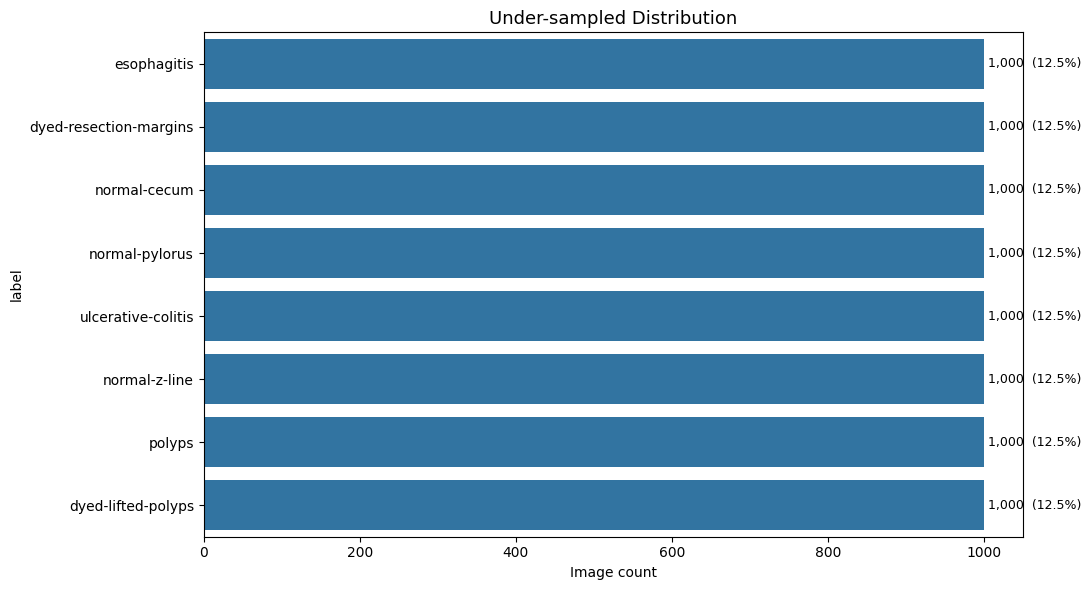

In [25]:
# REASON: Use median count as cap — it preserves the natural data regime of
# mid-tier classes instead of collapsing everything to the rarest pathology.
# Hardcoding 200 would discard ~99% of normal_clean_mucosa while still leaving
# a massive gap vs classes with only 10–20 images.
UNDER_CAP = int(counts.median())
print(f"UNDER_CAP (median class count): {UNDER_CAP}")

def undersample_df(df, cap):
    """
    Random under-sampling: cap MAJORITY classes at `cap`.
    Minority classes (below cap) are kept fully intact.
    """
    parts = []
    for lbl, group in df.groupby('label'):
        if len(group) > cap:
            # MAJORITY: randomly sample down to cap
            parts.append(group.sample(n=cap, random_state=SEED))
        else:
            # MINORITY: keep all samples untouched
            parts.append(group)
    return pd.concat(parts).sample(frac=1, random_state=SEED).reset_index(drop=True)


df_under = undersample_df(df_kvasir, UNDER_CAP)

print(f"Before under-sampling : {len(df_kvasir):,} rows")
print(f"After under-sampling  : {len(df_under):,} rows")
print(f"Data discarded        : {(1 - len(df_under)/len(df_kvasir))*100:.2f}%")
print(f"\nPer-class after under-sampling:")
print(df_under['label'].value_counts().to_string())

_, _ = plot_distribution(df_under, "Under-sampled Distribution")

**Observation:**
Under-sampling significantly reduces the dominant `normal_clean_mucosa` and `ileocecal_valve` classes, creating a more balanced gradient signal during training.
The tradeoff is substantial data loss from majority classes; however, minority classes retain all original samples, preserving the scarce pathological features the model must learn.
The median-based cap ensures mid-tier classes lose minimal data while majority classes are brought in line.

## TASK 3 — Augmentation-Based Over-Sampling (minority classes only)

In [26]:
# ============================================================
# AUGMENTATION PIPELINE
# All fill_mode="reflect" to avoid black border artifacts from
# the endoscope lens vignette merging with translation fill.
# ============================================================

# ---- Novel Augmentation 1: CutOut / Random Erasing ----
# REASON: Simulates partial occlusion from mucus/debris/bubbles
# which are real imaging artifacts in WCE frames.
class CutOut(tf.keras.layers.Layer):
    def __init__(self, mask_size=30, **kwargs):
        super().__init__(**kwargs)
        self.mask_size = mask_size

    def call(self, x, training=None):
        if not training:
            return x
        # x can be (H, W, C) or (B, H, W, C) — handle both
        shape = tf.shape(x)
        is_batched = (len(x.shape) == 4)
        img_h = shape[1] if is_batched else shape[0]
        img_w = shape[2] if is_batched else shape[1]
        ms    = self.mask_size

        # Clamp mask_size to actual image dimensions
        ms    = tf.minimum(ms, tf.minimum(img_h - 1, img_w - 1))

        y0 = tf.random.uniform((), 0, img_h - ms, dtype=tf.int32)
        x0 = tf.random.uniform((), 0, img_w - ms, dtype=tf.int32)

        ys = tf.range(y0, y0 + ms)
        xs = tf.range(x0, x0 + ms)
        gy, gx = tf.meshgrid(ys, xs, indexing='ij')
        coords = tf.stack([tf.reshape(gy, [-1]), tf.reshape(gx, [-1])], axis=1)

        if is_batched:
            # Apply to each image in batch independently
            def apply_to_single(img):
                c = tf.shape(img)[2]
                zeros = tf.zeros([ms * ms, c], dtype=img.dtype)
                return tf.tensor_scatter_nd_update(img, coords, zeros)
            return tf.map_fn(apply_to_single, x)
        else:
            c = tf.shape(x)[2]
            zeros = tf.zeros([ms * ms, c], dtype=x.dtype)
            return tf.tensor_scatter_nd_update(x, coords, zeros)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'mask_size': self.mask_size})
        return cfg


# ---- Novel Augmentation 2: Gaussian Noise Injection ----
# REASON: WCE cameras have sensor noise; injecting calibrated noise
# (stddev=0.02 ≈ 5/255) improves robustness to real hardware variation
# without degrading pathological texture visibility.
class GaussianNoise(tf.keras.layers.Layer):
    def __init__(self, stddev=0.02, **kwargs):
        super().__init__(**kwargs)
        self.stddev = stddev

    def call(self, x, training=None):
        if not training:
            return x
        noise = tf.random.normal(tf.shape(x), stddev=self.stddev)
        return tf.clip_by_value(x + noise, 0.0, 1.0)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'stddev': self.stddev})
        return cfg


# Full augmentation pipeline applied during decode for minority-class rows
# All operations on single images (H, W, C) — batching happens in make_ds
augmentation_pipeline = tf.keras.Sequential([
    # REASON: No anatomical left-right axis in WCE; flipping is label-preserving
    layers.RandomFlip('horizontal'),
    # REASON: Capsule tumbles freely in GI tract; reflect fill avoids black vignette artifacts
    layers.RandomRotation(0.15, fill_mode='reflect'),
    # REASON: Capped at 0.1 (not 0.2) to avoid cropping the diagnostic region of interest
    layers.RandomTranslation(0.1, 0.1, fill_mode='reflect'),
    # REASON: Simulates varying capsule-to-mucosa wall distance
    layers.RandomZoom(0.15, fill_mode='reflect'),
    # REASON: Adjusts for varying GI LED illumination intensity between frames
    layers.RandomContrast(0.15),
    # Novel 1: CutOut — simulates mucus/debris occlusion
    CutOut(mask_size=30),
    # Novel 2: Gaussian noise — simulates WCE sensor noise
    GaussianNoise(stddev=0.02),
], name='augmentation_pipeline')

print("Augmentation pipeline built.")

Augmentation pipeline built.


After over-sampling: 8,000 rows
  Originals (aug=False): 8,000
  Duplicates (aug=True): 0

Per-class after over-sampling:
label
normal-cecum              1000
normal-z-line             1000
normal-pylorus            1000
polyps                    1000
dyed-resection-margins    1000
ulcerative-colitis        1000
dyed-lifted-polyps        1000
esophagitis               1000


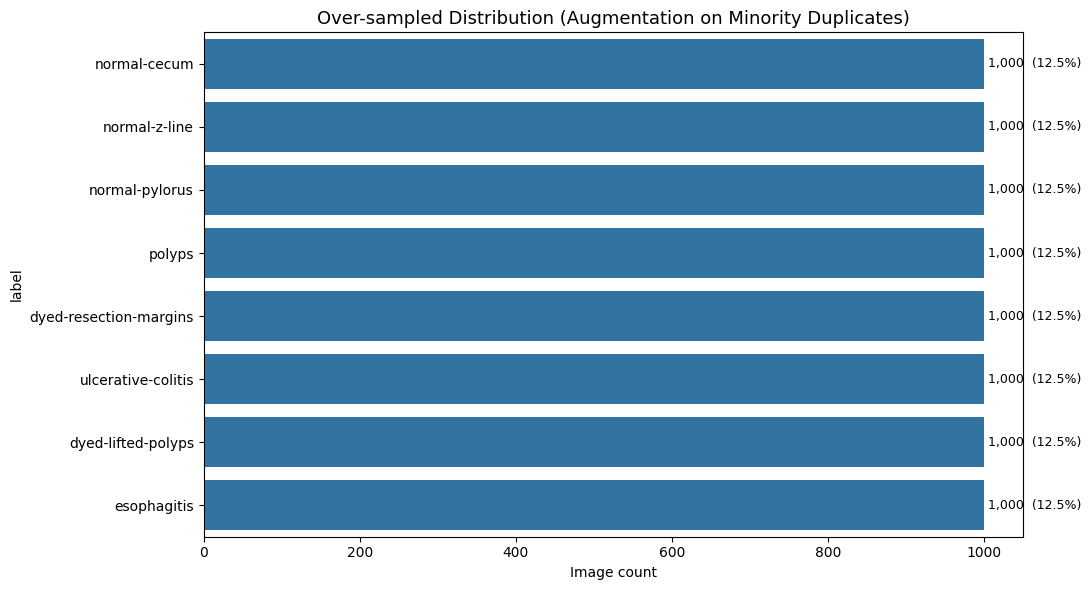

In [27]:
# ============================================================
# Over-sampling via row duplication — augmentation applied at
# decode time ONLY for duplicated (minority) rows.
# Strategy:
#   1. Start from df_under (majority already capped)
#   2. For each class below UNDER_CAP: duplicate rows with
#      replacement until it reaches UNDER_CAP
#   3. Mark duplicated rows with aug=True
#   4. Original rows keep aug=False
# This ensures augmentation is applied ONLY to minority class
# duplicates, not to majority class originals.
# ============================================================

def oversample_minority_df(df_undersampled, target):
    """
    Over-sample minority classes up to `target` by duplicating rows.
    Adds an 'aug' column: True for duplicated rows (will be augmented
    at decode time), False for original rows.

    Input: df_undersampled — already under-sampled DataFrame
    Only classes with fewer than `target` samples are over-sampled.
    """
    df = df_undersampled.copy()
    df['aug'] = False  # mark all originals as non-augmented

    parts = [df]  # start with all originals
    for lbl, group in df.groupby('label'):
        if len(group) < target:
            needed = target - len(group)
            # Sample with replacement from the minority class originals
            extra = group.sample(n=needed, replace=True, random_state=SEED).copy()
            extra['aug'] = True  # these duplicates WILL be augmented
            parts.append(extra)

    result = pd.concat(parts).sample(frac=1, random_state=SEED).reset_index(drop=True)
    return result


df_over = oversample_minority_df(df_under, UNDER_CAP)

print(f"After over-sampling: {len(df_over):,} rows")
print(f"  Originals (aug=False): {(~df_over['aug']).sum():,}")
print(f"  Duplicates (aug=True): {df_over['aug'].sum():,}")
print(f"\nPer-class after over-sampling:")
print(df_over['label'].value_counts().to_string())

_, _ = plot_distribution(df_over, "Over-sampled Distribution (Augmentation on Minority Duplicates)")

Rarest class: dyed-lifted-polyps


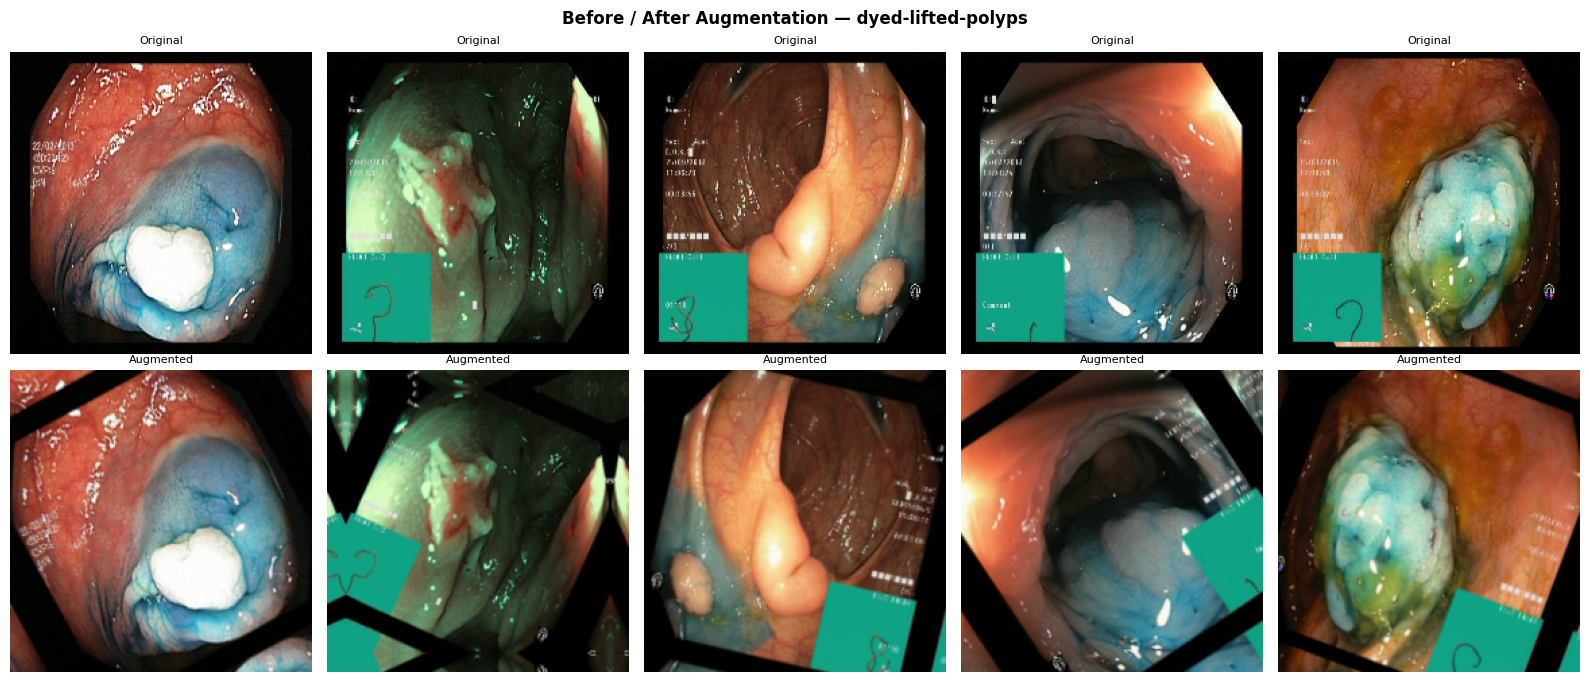


Dataset size summary:
  Baseline (raw)       :    8,000 images
  Under-sampled        :    8,000 images
  Under + Over-sampled :    8,000 images


In [28]:
# ============================================================
# Before/After augmentation preview for rarest class
# ============================================================
augmentation_pipeline = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.2),
])

def display_augmented_samples(df_source, class_name, num_samples=5):
    subset = df_source[df_source['label'] == class_name].drop_duplicates('path').head(num_samples)
    fig, axes = plt.subplots(2, len(subset), figsize=(3 * len(subset) + 1, 7))
    if len(subset) == 1:
        axes = [[axes[0]], [axes[1]]]

    for i, (_, row) in enumerate(subset.iterrows()):
        raw = tf.io.read_file(row['path'])
        raw = tf.image.decode_jpeg(raw, channels=3)
        raw = tf.image.resize(raw, IMG_SIZE)
        raw = tf.cast(raw, tf.float32) / 255.0

        # Augmented: expand_dims for pipeline, squeeze back
        aug_img = augmentation_pipeline(
            tf.expand_dims(raw, 0), training=True)[0]

        axes[0][i].imshow(raw.numpy())
        axes[0][i].set_title('Original', fontsize=8)
        axes[0][i].axis('off')

        axes[1][i].imshow(aug_img.numpy())
        axes[1][i].set_title('Augmented', fontsize=8)
        axes[1][i].axis('off')

    fig.suptitle(f'Before / After Augmentation — {class_name}', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()


rarest_class = df_kvasir['label'].value_counts().idxmin()

print("Rarest class:", rarest_class)

display_augmented_samples(df_kvasir, rarest_class, num_samples=5)

print("\nDataset size summary:")
print(f"  Baseline (raw)       : {len(df_kvasir):>8,} images")
print(f"  Under-sampled        : {len(df_under):>8,} images")
print(f"  Under + Over-sampled : {len(df_over):>8,} images")

• Random horizontal and vertical flips — exploit the rotational symmetry of WCE
capsule images, where pathological lesions have no canonical orientation.
• Random rotations — further diversify spatial appearance without introducing arte-facts, increasing geometric invariance.
• Random brightness and contrast jitter — simulate the illumination variability
inherent in capsule endoscopy hardware.
• Random zoom — encourage scale invariance for polyps and erosions that span vary-ing fractions of the frame.
• Cutout [8] — randomly masks a contiguous square region of pixels to zero, forcing the model to predict from partial observations. This regularises against over-reliance
on a single discriminative region, which is particularly beneficial for minority classes
that contain highly localised lesion textures (e.g. blood hematin, erythema).

* Gaussian noise injection [9] — adds zero-mean Gaussian noise (σ ∈ [0, 0.05]) to
pixel intensities, making the classifier robust to sensor noise and compression artefacts
present in real-world WCE video frames.

## Save DataFrames for Kaggle / External Use

In [29]:
# ============================================================
# Save the three DataFrames as CSVs.
# On Kaggle: update DATA_DIR and SAVE_DIR at the top,
# then load with pd.read_csv() — all other code is unchanged.
# df_over has an 'aug' column (bool) used by make_ds.
# df_kvasir and df_under have aug=False implicitly (no aug col).
# ============================================================

# Add aug=False column to baseline and undersampled for consistency

SAVE_DIR = "/kaggle/working/"

df_kvasir_save = df_kvasir.copy()
df_kvasir_save['aug'] = False

df_under_save = df_under.copy()
df_under_save['aug'] = False

baseline_path = os.path.join(SAVE_DIR, 'df_baseline.csv')
under_path    = os.path.join(SAVE_DIR, 'df_undersampled.csv')
over_path     = os.path.join(SAVE_DIR, 'df_oversampled.csv')

df_kvasir_save.to_csv(baseline_path, index=False)
df_under_save.to_csv(under_path,    index=False)
df_over.to_csv(over_path,           index=False)

print(f"Saved:")
print(f"  Baseline     -> {baseline_path}  ({len(df_kvasir_save):,} rows)")
print(f"  Under-sampled-> {under_path}  ({len(df_under_save):,} rows)")
print(f"  Over-sampled -> {over_path}  ({len(df_over):,} rows)")
print()
print("To reload on Kaggle:")
print("  df_kvasir = pd.read_csv('df_baseline.csv')")
print("  df_under  = pd.read_csv('df_undersampled.csv')")
print("  df_over   = pd.read_csv('df_oversampled.csv')")

Saved:
  Baseline     -> /kaggle/working/df_baseline.csv  (8,000 rows)
  Under-sampled-> /kaggle/working/df_undersampled.csv  (8,000 rows)
  Over-sampled -> /kaggle/working/df_oversampled.csv  (8,000 rows)

To reload on Kaggle:
  df_kvasir = pd.read_csv('df_baseline.csv')
  df_under  = pd.read_csv('df_undersampled.csv')
  df_over   = pd.read_csv('df_oversampled.csv')


## TASK 4 — Data Preprocessing, Splitting, tf.data Pipeline

In [30]:
SPLITS = {'train': 0.70, 'val': 0.15, 'test': 0.15}

def split_df(df):
    """
    Stratified train/val/test split.
    REASON: StratifiedShuffleSplit guarantees all classes appear in every
    split — random iloc slicing can put 0 samples of a rare class in val/test.
    """
    # Drop aug column before splitting (re-added after)
    has_aug = 'aug' in df.columns
    sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=SEED)
    train_idx, temp_idx = next(sss1.split(df, df['label']))
    train_df = df.iloc[train_idx].reset_index(drop=True)
    temp_df  = df.iloc[temp_idx].reset_index(drop=True)

    sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=SEED)
    val_idx, test_idx = next(sss2.split(temp_df, temp_df['label']))
    val_df  = temp_df.iloc[val_idx].reset_index(drop=True)
    test_df = temp_df.iloc[test_idx].reset_index(drop=True)

    return train_df, val_df, test_df


# ============================================================
# Split each of the three datasets separately.
# Val and test always come from the BASELINE (real distribution)
# so evaluation reflects true clinical prevalence.
# Only the training portion varies per setting.
# ============================================================
train_baseline, val_df, test_df = split_df(df_kvasir_save)
train_under,    _,      _       = split_df(df_under_save)
train_over,     _,      _       = split_df(df_over)

print(f"Val  size : {len(val_df):,}  | Test size: {len(test_df):,}")
print(f"Train — baseline   : {len(train_baseline):,}")
print(f"Train — under      : {len(train_under):,}")
print(f"Train — under+over : {len(train_over):,}")

Val  size : 1,200  | Test size: 1,200
Train — baseline   : 5,600
Train — under      : 5,600
Train — under+over : 5,600


In [31]:
# ============================================================
# tf.data pipeline
# FIX: decode_example must NOT be decorated with @tf.function
# when `aug` is a Python bool captured in a closure — TF traces
# the function once and bakes `aug` as a constant at trace time,
# so all subsequent calls use the traced value regardless of input.
# Solution: wrap only the augmentation call in @tf.function.
# ============================================================

@tf.function(reduce_retracing=True)
def _apply_aug(img):
    """Apply augmentation pipeline to a single (H, W, C) image tensor."""
    return augmentation_pipeline(
        tf.expand_dims(img, 0), training=True)[0]


def decode_example(path, label, do_aug):
    """
    Decode one example. `do_aug` is a tf.bool tensor (0 or 1),
    derived from the 'aug' column of the DataFrame.
    tf.cond selects augmented vs raw path at graph level.
    """
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    img = tf.cond(do_aug,
                  lambda: _apply_aug(img),
                  lambda: img)
    return img, label


def make_ds(df, shuffle=False):
    """
    Build a tf.data.Dataset from a DataFrame.
    The 'aug' column (bool) controls per-sample augmentation:
      - aug=True  : apply full augmentation pipeline (minority duplicates)
      - aug=False : raw decode only (originals and all val/test samples)
    """
    paths  = df['path'].values
    labels = np.array([class_to_idx[l] for l in df['label'].values], dtype=np.int32)
    augs   = df['aug'].values.astype(bool) if 'aug' in df.columns \
             else np.zeros(len(df), dtype=bool)

    ds = tf.data.Dataset.from_tensor_slices(
        (paths, labels, augs.astype(np.int32))  # pass aug as int (0/1) for tf.bool
    )
    if shuffle:
        ds = ds.shuffle(len(df), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(
        lambda p, l, a: decode_example(p, l, tf.cast(a, tf.bool)),
        num_parallel_calls=AUTOTUNE,
        deterministic=False
    )
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)


# Build the four training datasets + shared val/test
train_ds_baseline = make_ds(train_baseline, shuffle=True)
train_ds_under    = make_ds(train_under,    shuffle=True)
train_ds_over     = make_ds(train_over,     shuffle=True)
val_ds            = make_ds(val_df,         shuffle=False)
test_ds           = make_ds(test_df,        shuffle=False)

# Verify batch shape
for imgs, lbls in train_ds_baseline.take(1):
    print('Baseline batch shape  :', imgs.shape)   # expect (32, 224, 224, 3)
    assert imgs.shape[1:] == (224, 224, 3)

for imgs, lbls in train_ds_over.take(1):
    print('Over-sampled batch shape:', imgs.shape)
    assert imgs.shape[1:] == (224, 224, 3)

print('\nAll datasets built successfully.')

Baseline batch shape  : (32, 224, 224, 3)
Over-sampled batch shape: (32, 224, 224, 3)

All datasets built successfully.


## TASK 5 — Transfer Learning Model Design

In [32]:
# ============================================================
# Model builder
# Using EfficientNetB0, MobileNetV2, ResNet101V2
# NOTE: InceptionV3 requires (299,299) input — using ResNet101V2
# instead to keep a consistent 224x224 input across all models.
# ============================================================

def build_model(backbone_fn, name):
    """
    backbone_fn : one of EfficientNetB0, MobileNetV2, ResNet101V2
    name        : string label for the model
    """
    base = backbone_fn(
        weights='imagenet',
        include_top=False,
        input_shape=(224, 224, 3)
    )

    # Freeze everything except BatchNormalization.
    # REASON: BN layers must stay in inference mode during frozen phase
    # to preserve ImageNet feature statistics. Updating BN running mean/var
    # with a small medical-image batch would corrupt the pretrained representations.
    for layer in base.layers:
        layer.trainable = isinstance(layer, layers.BatchNormalization)

    inp = layers.Input(shape=(224, 224, 3))
    x   = base(inp, training=False)  # training=False keeps BN in inference mode
    x   = layers.GlobalAveragePooling2D()(x)

    # REASON: Dropout(0.4) before dense — aggressive enough to prevent
    # the head memorising augmented minority samples.
    x = layers.Dropout(0.4)(x)

    # REASON: Dense(256) bottleneck — compresses backbone features to a
    # task-specific representation; L2(1e-4) is stronger than ImageNet
    # standard (1e-5) because our dataset is small.
    x = layers.Dense(256, activation='relu',
                     kernel_regularizer=regularizers.L2(1e-4))(x)

    # REASON: Dropout(0.3) before softmax prevents overconfident predictions
    # on rare classes that have limited training samples.
    x       = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs=inp, outputs=outputs, name=name)
    return model, base


def print_model_summary(model):
    total      = model.count_params()
    trainable  = sum(tf.size(w).numpy() for w in model.trainable_weights)
    frozen     = total - trainable
    print(f"\n{model.name}")
    print(f"  Total params     : {total:>12,}")
    print(f"  Trainable params : {trainable:>12,}")
    print(f"  Frozen params    : {frozen:>12,}")
    print("  Last 6 layers:")
    for layer in model.layers[-6:]:
        print(f"    {layer.name:<40} trainable={layer.trainable}")


eff_model, eff_base = build_model(EfficientNetB0, 'EfficientNetB0')
mob_model, mob_base = build_model(MobileNetV2,    'MobileNetV2')
res_model, res_base = build_model(ResNet101V2,    'ResNet101V2')

for m in [eff_model, mob_model, res_model]:
    print_model_summary(m)


EfficientNetB0
  Total params     :    4,379,563
  Trainable params :      372,008
  Frozen params    :    4,007,555
  Last 6 layers:
    efficientnetb0                           trainable=True
    global_average_pooling2d_1               trainable=True
    dropout_2                                trainable=True
    dense_2                                  trainable=True
    dropout_3                                trainable=True
    dense_3                                  trainable=True

MobileNetV2
  Total params     :    2,587,976
  Trainable params :      364,104
  Frozen params    :    2,223,872
  Last 6 layers:
    mobilenetv2_1.00_224                     trainable=True
    global_average_pooling2d_2               trainable=True
    dropout_4                                trainable=True
    dense_4                                  trainable=True
    dropout_5                                trainable=True
    dense_5                                  trainable=True

ResNet101V2


## TASK 6 — Intelligent Learning Rate Control

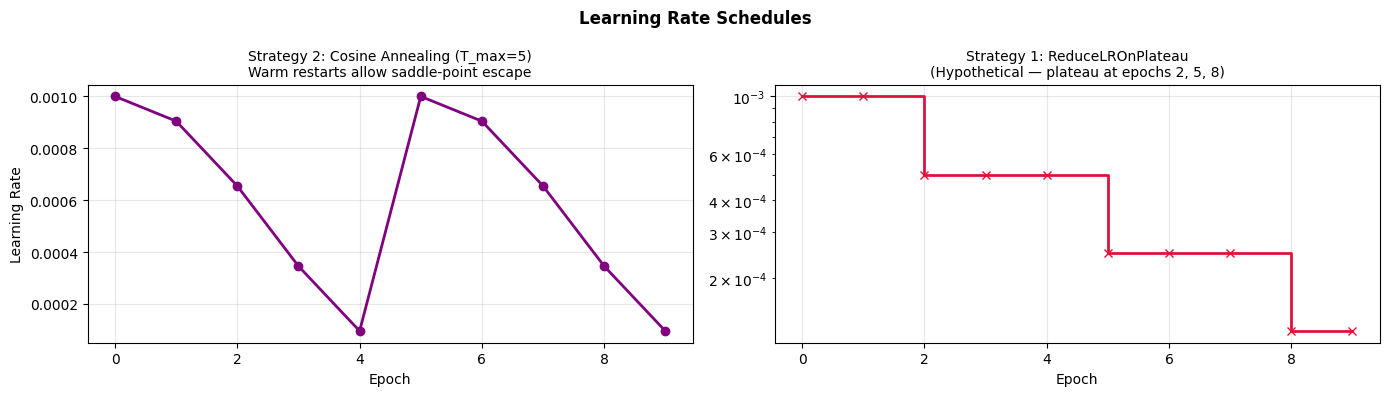

In [33]:
LR_BASE = 1e-3

# ---- Strategy 1: ReduceLROnPlateau ----
# REASON: factor=0.5 halves LR conservatively — avoids overshooting the
# shallow loss landscape of a frozen-base model.
# patience=3 avoids premature reduction due to noisy val_loss on small
# minority classes that cause high epoch-to-epoch metric variance.
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=3,
    min_lr=1e-7, verbose=1
)

# ---- Strategy 2: Cosine Annealing with Warm Restarts ----
# REASON: Warm restarts help escape sharp minima caused by imbalanced
# gradients. The periodic LR reset allows re-exploration of the loss
# surface after each restart cycle, often finding flatter minima.
def cosine_schedule(epoch, lr=None, T_max=5):
    # float() is REQUIRED — keras LearningRateScheduler rejects tensors
    completed = (epoch % T_max) / T_max
    return float(LR_BASE * 0.5 * (1.0 + math.cos(math.pi * completed)))

cosine_lr = LearningRateScheduler(cosine_schedule, verbose=0)

# ---- Plot both strategies over 10 epochs ----
epochs_test = np.arange(10)
cos_lrs  = [cosine_schedule(e) for e in epochs_test]
# Simulate ReduceLROnPlateau: plateau at epoch 2, 5, 8
plat_lrs = [LR_BASE] * 2 + [LR_BASE * 0.5] * 3 + \
           [LR_BASE * 0.25] * 3 + [LR_BASE * 0.125] * 2

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(epochs_test, cos_lrs, marker='o', color='purple', linewidth=2)
axes[0].set_title('Strategy 2: Cosine Annealing (T_max=5)\nWarm restarts allow saddle-point escape', fontsize=10)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Learning Rate')
axes[0].grid(True, alpha=0.3)

axes[1].step(epochs_test, plat_lrs, where='post', marker='x', color='crimson', linewidth=2)
axes[1].set_title('Strategy 1: ReduceLROnPlateau\n(Hypothetical — plateau at epochs 2, 5, 8)', fontsize=10)
axes[1].set_xlabel('Epoch')
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Learning Rate Schedules', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## TASK 7 — Training and Evaluation

In [34]:
# ============================================================
# Helpers
# ============================================================

def compile_model(model, lr):
    """
    REASON: Only 'accuracy' as Keras metric — Precision/Recall suffer
    from a batch-level confusion matrix shape mismatch bug in Keras 3
    for multi-class problems when batch sizes vary.
    All detailed metrics are computed post-training via sklearn.
    """
    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=lr,
            # REASON: weight_decay regularises Adam implicitly;
            # combined with L2 in Dense layers = double regularisation
            # for a small-data medical setting
            weight_decay=1e-5
        ),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model  # FIX: original code didn't return model


def compute_metrics(model, ds, setting_name):
    y_true, y_pred = [], []
    for imgs, lbls in ds:
        preds = model.predict(imgs, verbose=0)
        y_pred.extend(np.argmax(preds, axis=1).tolist())
        y_true.extend(lbls.numpy().tolist())

    print(f"\n{'='*60}")
    print(f"Evaluation Report: {setting_name}")
    print(f"{'='*60}")
    print(classification_report(
        y_true, y_pred,
        target_names=class_names,
        zero_division=0
    ))

    mac_f1   = f1_score(y_true, y_pred, average='macro',    zero_division=0)
    wei_f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    mac_rec  = recall_score(y_true, y_pred, average='macro', zero_division=0)
    acc      = np.mean(np.array(y_true) == np.array(y_pred))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(11, 9))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                annot_kws={'size': 7})
    plt.title(f'Confusion Matrix: {setting_name}', fontsize=12)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.xticks(rotation=45, ha='right', fontsize=8)
    plt.yticks(rotation=0, fontsize=8)
    plt.tight_layout()
    plt.show()

    return {
        'test_accuracy': round(acc, 4),
        'macro_f1':      round(mac_f1, 4),
        'weighted_f1':   round(wei_f1, 4),
        'macro_recall':  round(mac_rec, 4)
    }


def get_fresh_model(name):
    """
    Always rebuild from scratch to guarantee clean weights.
    REASON: clear_session() frees GPU memory between experiments.
    """
    tf.keras.backend.clear_session()
    tf.random.set_seed(SEED)
    if name == 'EfficientNetB0':
        return build_model(EfficientNetB0, name)
    elif name == 'MobileNetV2':
        return build_model(MobileNetV2, name)
    elif name == 'ResNet101V2':
        return build_model(ResNet101V2, name)
    else:
        raise ValueError(f'Unknown model: {name}')


print('Helpers defined.')

Helpers defined.



#################################################################
  EfficientNetB0__baseline
#################################################################

>> Phase 1: Frozen base, 10 epochs, LR=0.001
Epoch 1/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 86s 230ms/step - accuracy: 0.5606 - loss: 1.2026 - val_accuracy: 0.1158 - val_loss: 2.2190 - learning_rate: 0.0010
Epoch 2/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 30s 169ms/step - accuracy: 0.8139 - loss: 0.5099 - val_accuracy: 0.1692 - val_loss: 2.2587 - learning_rate: 9.0451e-04
Epoch 3/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 30s 171ms/step - accuracy: 0.8426 - loss: 0.4223 - val_accuracy: 0.5783 - val_loss: 1.1864 - learning_rate: 6.5451e-04
Epoch 4/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 30s 171ms/step - accuracy: 0.8735 - loss: 0.3605 - val_accuracy: 0.8133 - val_loss: 0.5401 - learning_rate: 3.4549e-04
Epoch 5/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 30s 170ms/step - accuracy: 0.8914 - loss: 0.3296 - val_accuracy: 0.8725 - val_loss: 0.3766 - learning_rate: 9.5492e-05
Epo

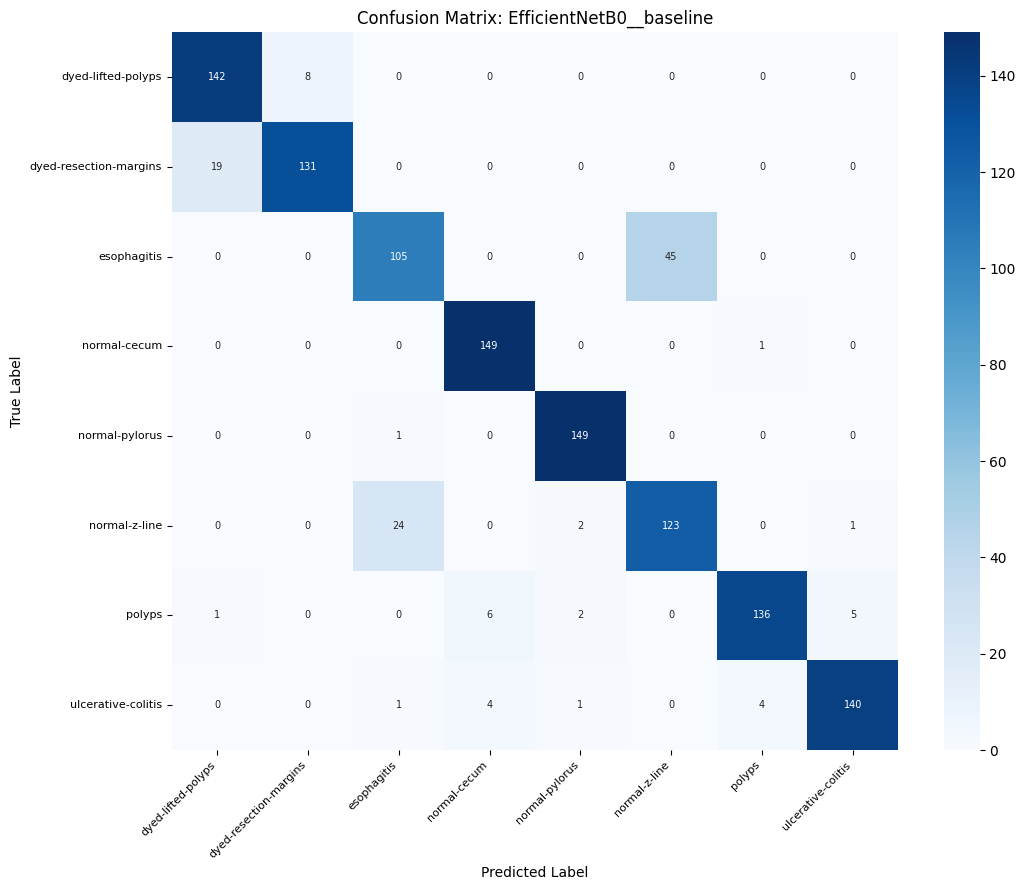

  >> New best: macro_f1=0.8954

#################################################################
  EfficientNetB0__under
#################################################################

>> Phase 1: Frozen base, 10 epochs, LR=0.001
Epoch 1/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 84s 224ms/step - accuracy: 0.5415 - loss: 1.2196 - val_accuracy: 0.0517 - val_loss: 2.2059 - learning_rate: 0.0010
Epoch 2/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 30s 170ms/step - accuracy: 0.7970 - loss: 0.5471 - val_accuracy: 0.2242 - val_loss: 2.1869 - learning_rate: 9.0451e-04
Epoch 3/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 30s 169ms/step - accuracy: 0.8503 - loss: 0.4247 - val_accuracy: 0.5958 - val_loss: 1.1200 - learning_rate: 6.5451e-04
Epoch 4/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 29s 168ms/step - accuracy: 0.8700 - loss: 0.3688 - val_accuracy: 0.8067 - val_loss: 0.5290 - learning_rate: 3.4549e-04
Epoch 5/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 30s 169ms/step - accuracy: 0.8709 - loss: 0.3576 - val_accuracy: 0.9058 - val_loss: 0.2965 - l

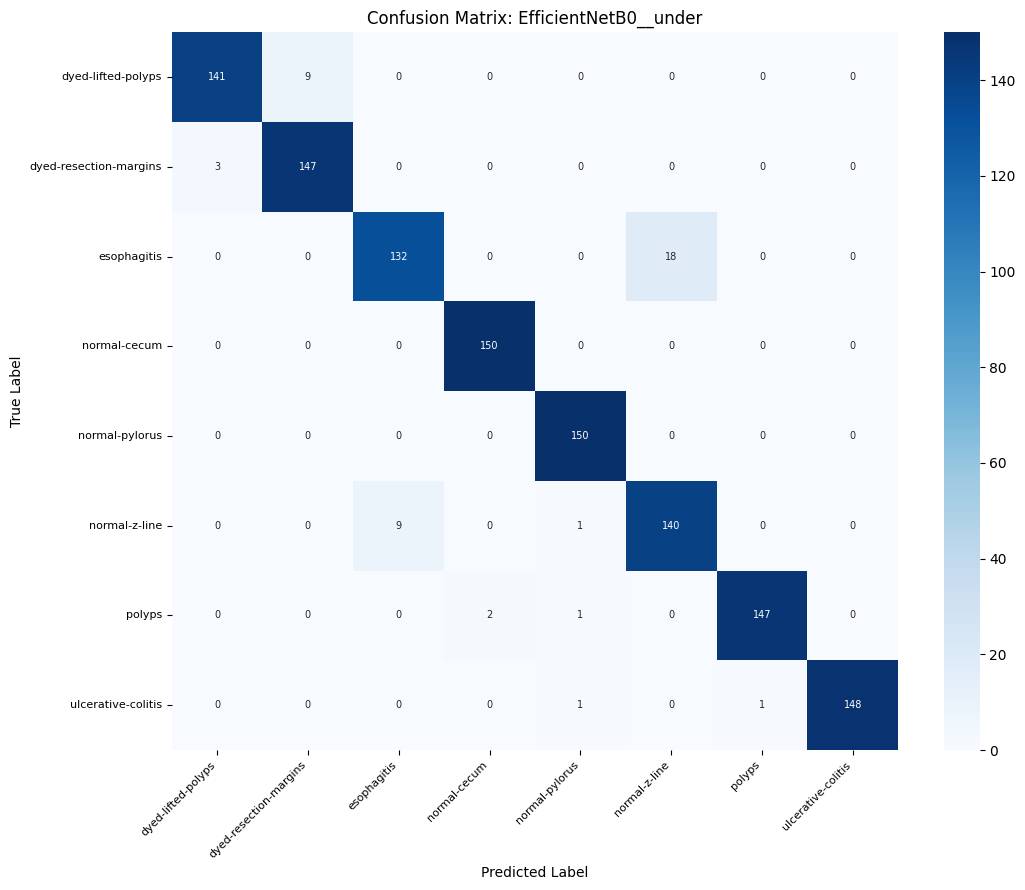

  >> New best: macro_f1=0.9625

#################################################################
  EfficientNetB0__under_over
#################################################################

>> Phase 1: Frozen base, 10 epochs, LR=0.001
Epoch 1/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 85s 225ms/step - accuracy: 0.5341 - loss: 1.2342 - val_accuracy: 0.1150 - val_loss: 2.1395 - learning_rate: 0.0010
Epoch 2/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 29s 167ms/step - accuracy: 0.8105 - loss: 0.5148 - val_accuracy: 0.1917 - val_loss: 2.1581 - learning_rate: 9.0451e-04
Epoch 3/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 29s 167ms/step - accuracy: 0.8562 - loss: 0.4190 - val_accuracy: 0.5908 - val_loss: 1.0964 - learning_rate: 6.5451e-04
Epoch 4/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 30s 168ms/step - accuracy: 0.8689 - loss: 0.3683 - val_accuracy: 0.8183 - val_loss: 0.5025 - learning_rate: 3.4549e-04
Epoch 5/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 29s 167ms/step - accuracy: 0.8788 - loss: 0.3544 - val_accuracy: 0.9075 - val_loss: 0.299

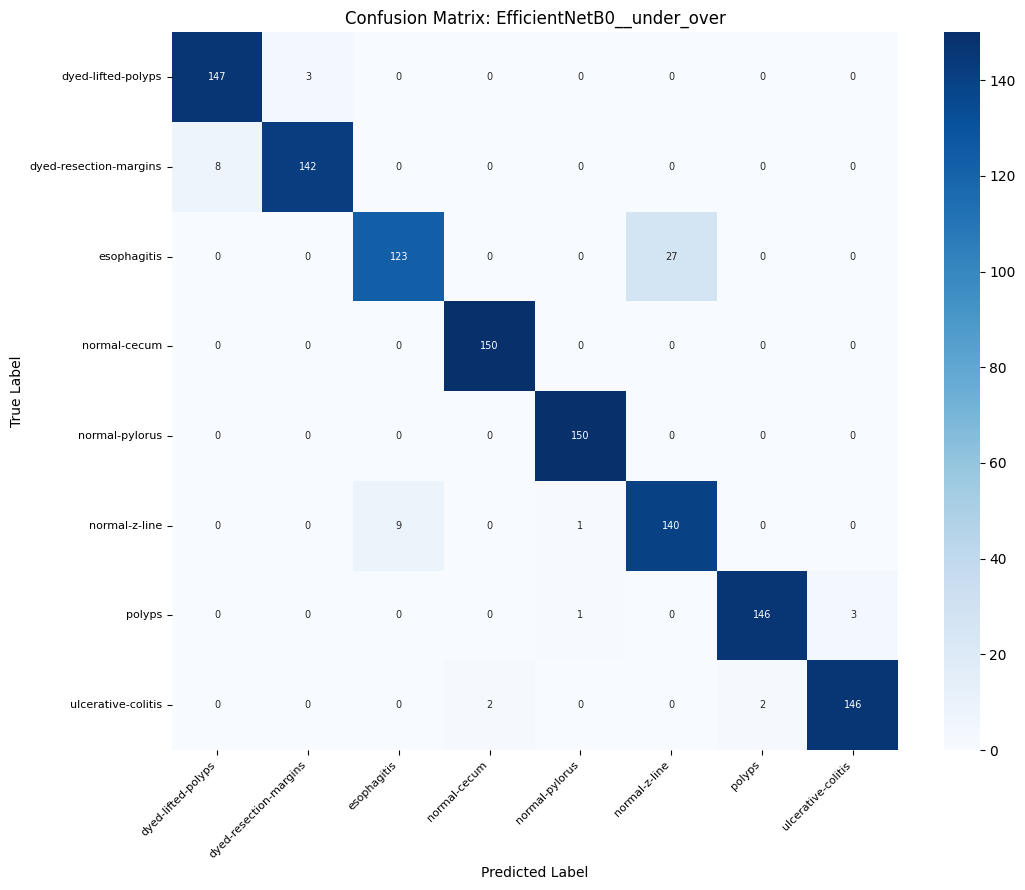


#################################################################
  MobileNetV2__baseline
#################################################################

>> Phase 1: Frozen base, 10 epochs, LR=0.001
Epoch 1/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 66s 186ms/step - accuracy: 0.5208 - loss: 1.3215 - val_accuracy: 0.4225 - val_loss: 1.7893 - learning_rate: 0.0010
Epoch 2/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 25s 144ms/step - accuracy: 0.7898 - loss: 0.5705 - val_accuracy: 0.5042 - val_loss: 1.8122 - learning_rate: 9.0451e-04
Epoch 3/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 25s 144ms/step - accuracy: 0.8452 - loss: 0.4559 - val_accuracy: 0.6242 - val_loss: 1.1609 - learning_rate: 6.5451e-04
Epoch 4/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 25s 145ms/step - accuracy: 0.8728 - loss: 0.3638 - val_accuracy: 0.6942 - val_loss: 0.9466 - learning_rate: 3.4549e-04
Epoch 5/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 25s 145ms/step - accuracy: 0.8716 - loss: 0.3696 - val_accuracy: 0.7392 - val_loss: 0.7952 - learning_rate: 9.5492e-05
Epoch 

2026-03-26 18:43:35.607945: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-26 18:43:35.805092: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


175/175 ━━━━━━━━━━━━━━━━━━━━ 68s 186ms/step - accuracy: 0.9209 - loss: 0.2437 - val_accuracy: 0.8692 - val_loss: 0.4314 - learning_rate: 1.0000e-04
Epoch 2/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 26s 146ms/step - accuracy: 0.9541 - loss: 0.1714 - val_accuracy: 0.8817 - val_loss: 0.4461 - learning_rate: 1.0000e-04
Epoch 3/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 26s 145ms/step - accuracy: 0.9631 - loss: 0.1464 - val_accuracy: 0.8792 - val_loss: 0.4636 - learning_rate: 1.0000e-04
Epoch 4/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.9742 - loss: 0.1249
Epoch 4: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
175/175 ━━━━━━━━━━━━━━━━━━━━ 26s 146ms/step - accuracy: 0.9742 - loss: 0.1248 - val_accuracy: 0.8833 - val_loss: 0.4657 - learning_rate: 1.0000e-04
Epoch 5/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 26s 146ms/step - accuracy: 0.9847 - loss: 0.0885 - val_accuracy: 0.8875 - val_loss: 0.4795 - learning_rate: 5.0000e-05

Evaluation Report: MobileNetV2__baseline
                        p

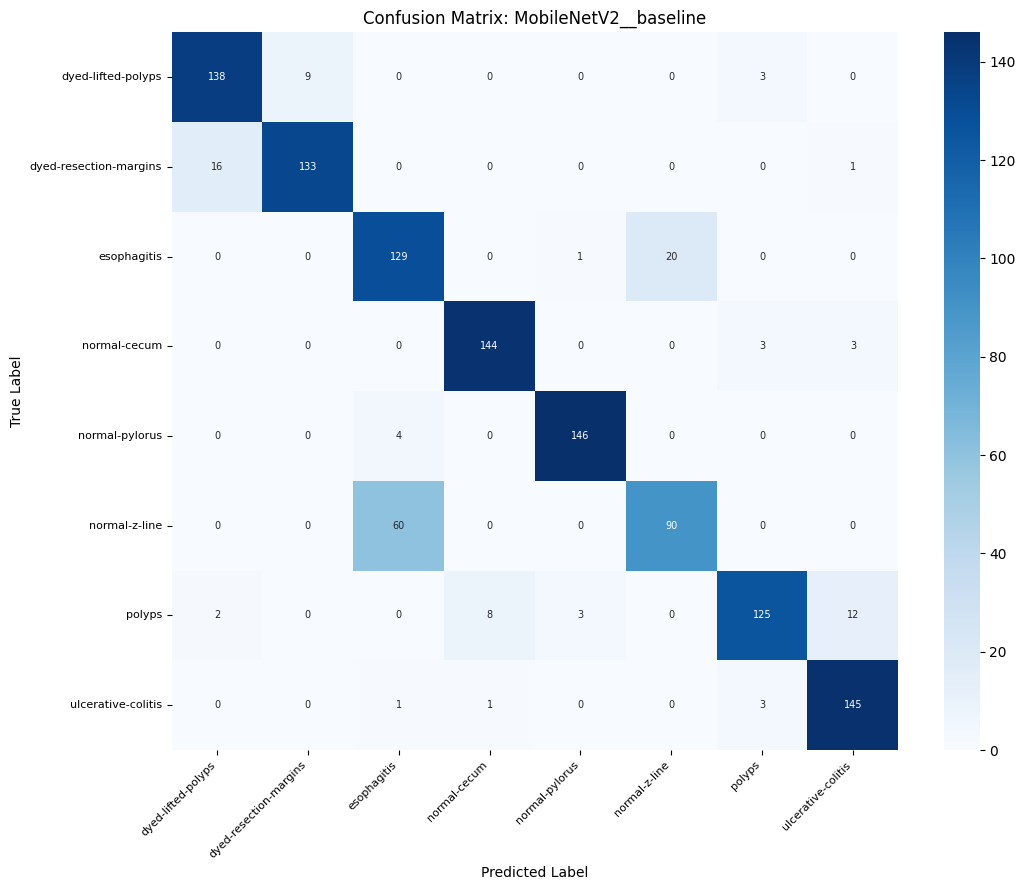


#################################################################
  MobileNetV2__under
#################################################################

>> Phase 1: Frozen base, 10 epochs, LR=0.001
Epoch 1/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 65s 185ms/step - accuracy: 0.5087 - loss: 1.3113 - val_accuracy: 0.4350 - val_loss: 1.5782 - learning_rate: 0.0010
Epoch 2/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 25s 143ms/step - accuracy: 0.7844 - loss: 0.5589 - val_accuracy: 0.5500 - val_loss: 1.3630 - learning_rate: 9.0451e-04
Epoch 3/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 25s 144ms/step - accuracy: 0.8369 - loss: 0.4384 - val_accuracy: 0.6283 - val_loss: 1.1237 - learning_rate: 6.5451e-04
Epoch 4/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 25s 144ms/step - accuracy: 0.8630 - loss: 0.3796 - val_accuracy: 0.7350 - val_loss: 0.7653 - learning_rate: 3.4549e-04
Epoch 5/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 25s 144ms/step - accuracy: 0.8761 - loss: 0.3480 - val_accuracy: 0.7908 - val_loss: 0.6312 - learning_rate: 9.5492e-05
Epoch 6/1

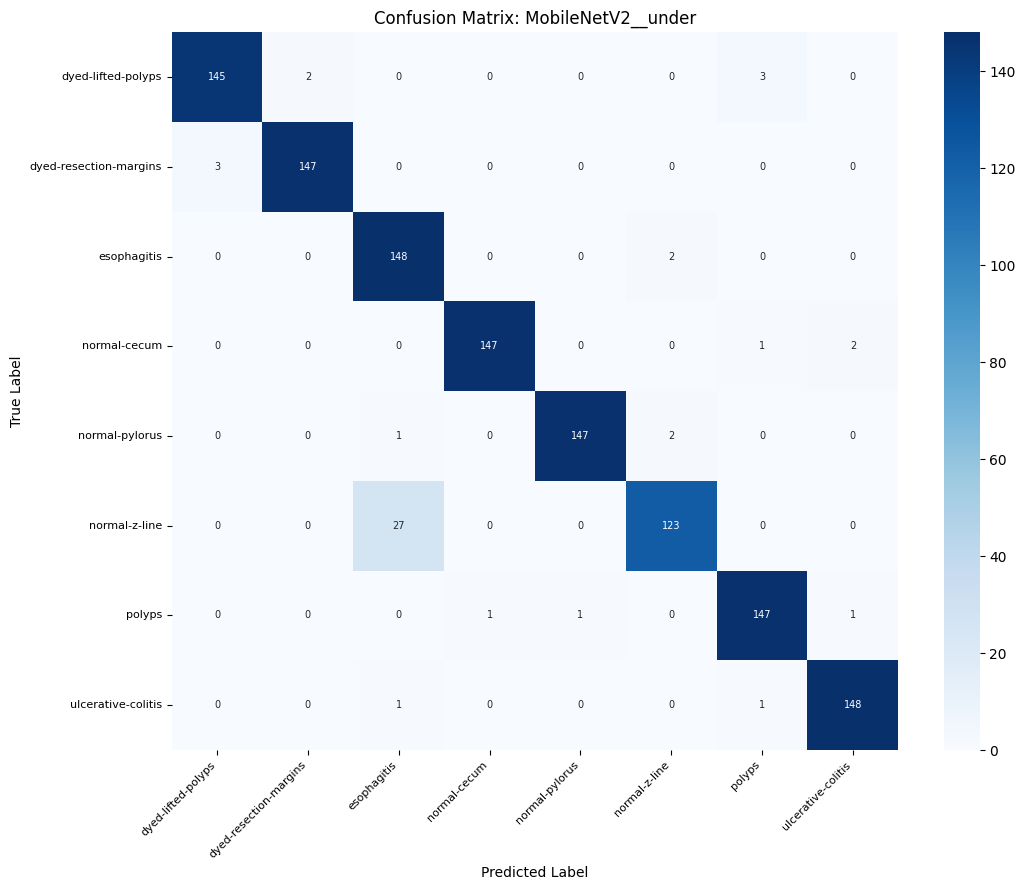


#################################################################
  MobileNetV2__under_over
#################################################################

>> Phase 1: Frozen base, 10 epochs, LR=0.001
Epoch 1/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 66s 186ms/step - accuracy: 0.5126 - loss: 1.3113 - val_accuracy: 0.5325 - val_loss: 1.3749 - learning_rate: 0.0010
Epoch 2/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 26s 145ms/step - accuracy: 0.8010 - loss: 0.5508 - val_accuracy: 0.4775 - val_loss: 2.1540 - learning_rate: 9.0451e-04
Epoch 3/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 25s 144ms/step - accuracy: 0.8369 - loss: 0.4440 - val_accuracy: 0.5883 - val_loss: 1.4457 - learning_rate: 6.5451e-04
Epoch 4/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 26s 146ms/step - accuracy: 0.8787 - loss: 0.3609 - val_accuracy: 0.6450 - val_loss: 1.1909 - learning_rate: 3.4549e-04
Epoch 5/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 26s 146ms/step - accuracy: 0.8763 - loss: 0.3542 - val_accuracy: 0.7167 - val_loss: 0.8887 - learning_rate: 9.5492e-05
Epoc

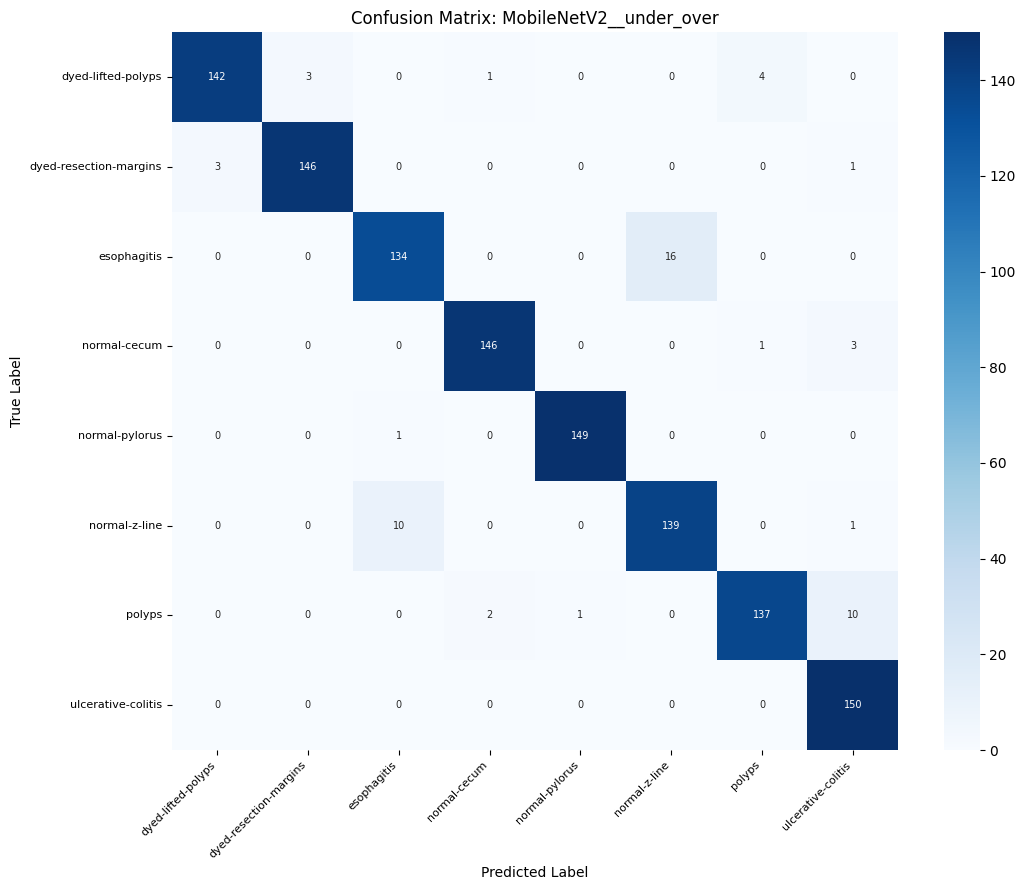


#################################################################
  ResNet101V2__baseline
#################################################################

>> Phase 1: Frozen base, 10 epochs, LR=0.001
Epoch 1/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 123s 321ms/step - accuracy: 0.5881 - loss: 1.1811 - val_accuracy: 0.8483 - val_loss: 0.4321 - learning_rate: 0.0010
Epoch 2/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 46s 263ms/step - accuracy: 0.8352 - loss: 0.4730 - val_accuracy: 0.8800 - val_loss: 0.3591 - learning_rate: 9.0451e-04
Epoch 3/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 46s 263ms/step - accuracy: 0.8793 - loss: 0.3516 - val_accuracy: 0.8775 - val_loss: 0.3557 - learning_rate: 6.5451e-04
Epoch 4/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 46s 263ms/step - accuracy: 0.8963 - loss: 0.3033 - val_accuracy: 0.8858 - val_loss: 0.3354 - learning_rate: 3.4549e-04
Epoch 5/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 46s 264ms/step - accuracy: 0.9115 - loss: 0.2676 - val_accuracy: 0.8942 - val_loss: 0.3319 - learning_rate: 9.5492e-05
Epoch

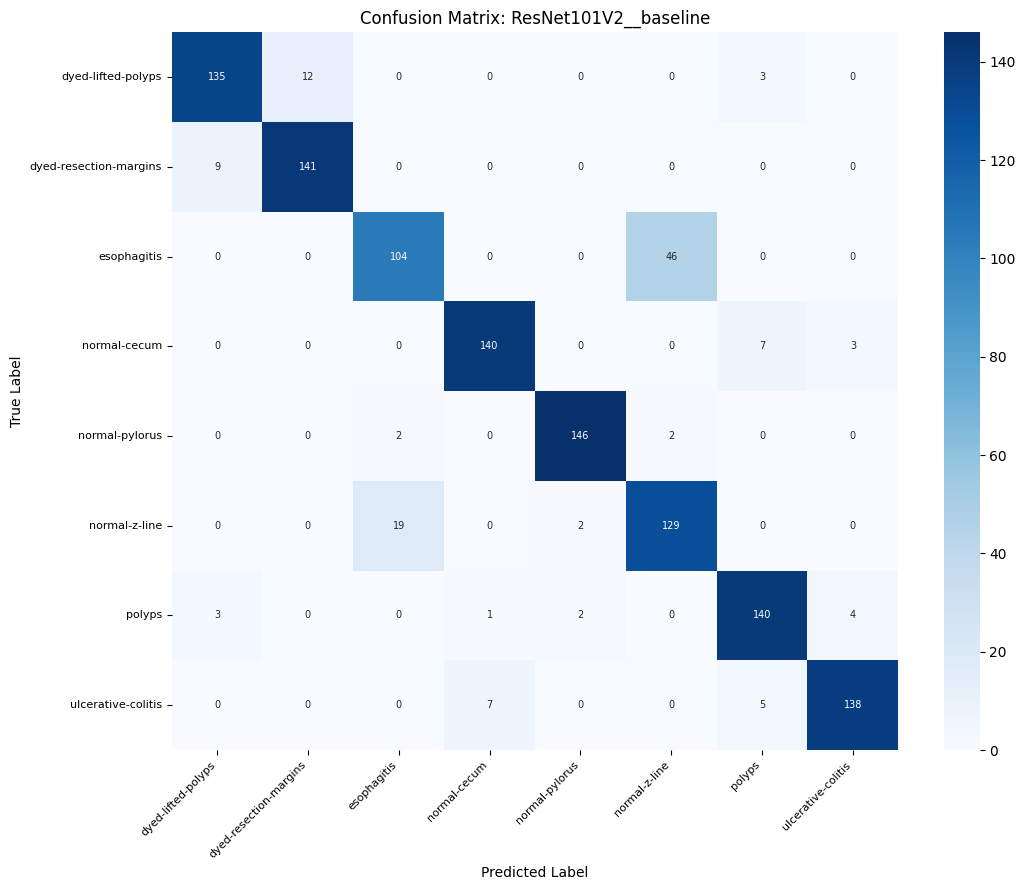


#################################################################
  ResNet101V2__under
#################################################################

>> Phase 1: Frozen base, 10 epochs, LR=0.001
Epoch 1/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 118s 313ms/step - accuracy: 0.5878 - loss: 1.1697 - val_accuracy: 0.8800 - val_loss: 0.3626 - learning_rate: 0.0010
Epoch 2/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 46s 263ms/step - accuracy: 0.8424 - loss: 0.4417 - val_accuracy: 0.9150 - val_loss: 0.2780 - learning_rate: 9.0451e-04
Epoch 3/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 46s 263ms/step - accuracy: 0.8705 - loss: 0.3694 - val_accuracy: 0.9317 - val_loss: 0.2408 - learning_rate: 6.5451e-04
Epoch 4/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 46s 263ms/step - accuracy: 0.8991 - loss: 0.3071 - val_accuracy: 0.9483 - val_loss: 0.2207 - learning_rate: 3.4549e-04
Epoch 5/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 46s 263ms/step - accuracy: 0.9031 - loss: 0.2798 - val_accuracy: 0.9450 - val_loss: 0.2154 - learning_rate: 9.5492e-05
Epoch 6/

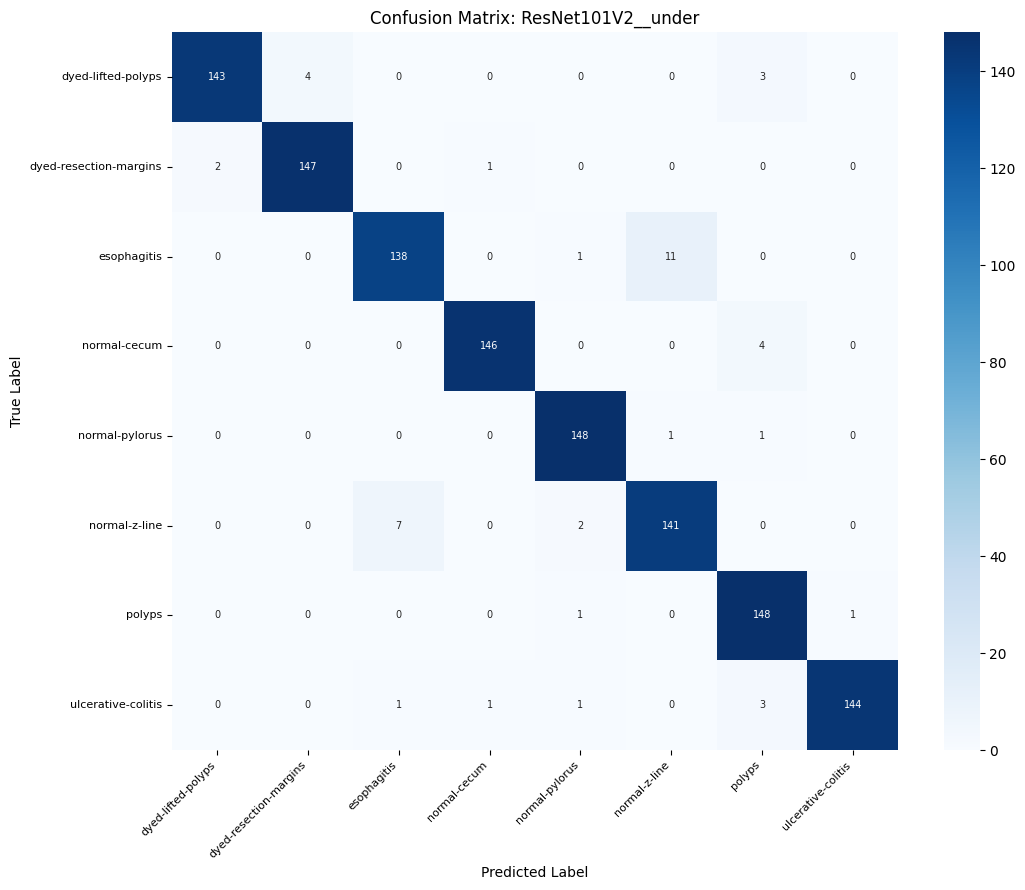


#################################################################
  ResNet101V2__under_over
#################################################################

>> Phase 1: Frozen base, 10 epochs, LR=0.001
Epoch 1/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 118s 314ms/step - accuracy: 0.6002 - loss: 1.1469 - val_accuracy: 0.8758 - val_loss: 0.3630 - learning_rate: 0.0010
Epoch 2/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 46s 264ms/step - accuracy: 0.8399 - loss: 0.4469 - val_accuracy: 0.9133 - val_loss: 0.2730 - learning_rate: 9.0451e-04
Epoch 3/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 46s 264ms/step - accuracy: 0.8692 - loss: 0.3697 - val_accuracy: 0.9217 - val_loss: 0.2559 - learning_rate: 6.5451e-04
Epoch 4/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 46s 263ms/step - accuracy: 0.8969 - loss: 0.3217 - val_accuracy: 0.9350 - val_loss: 0.2308 - learning_rate: 3.4549e-04
Epoch 5/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 46s 263ms/step - accuracy: 0.9121 - loss: 0.2739 - val_accuracy: 0.9333 - val_loss: 0.2267 - learning_rate: 9.5492e-05
Epo

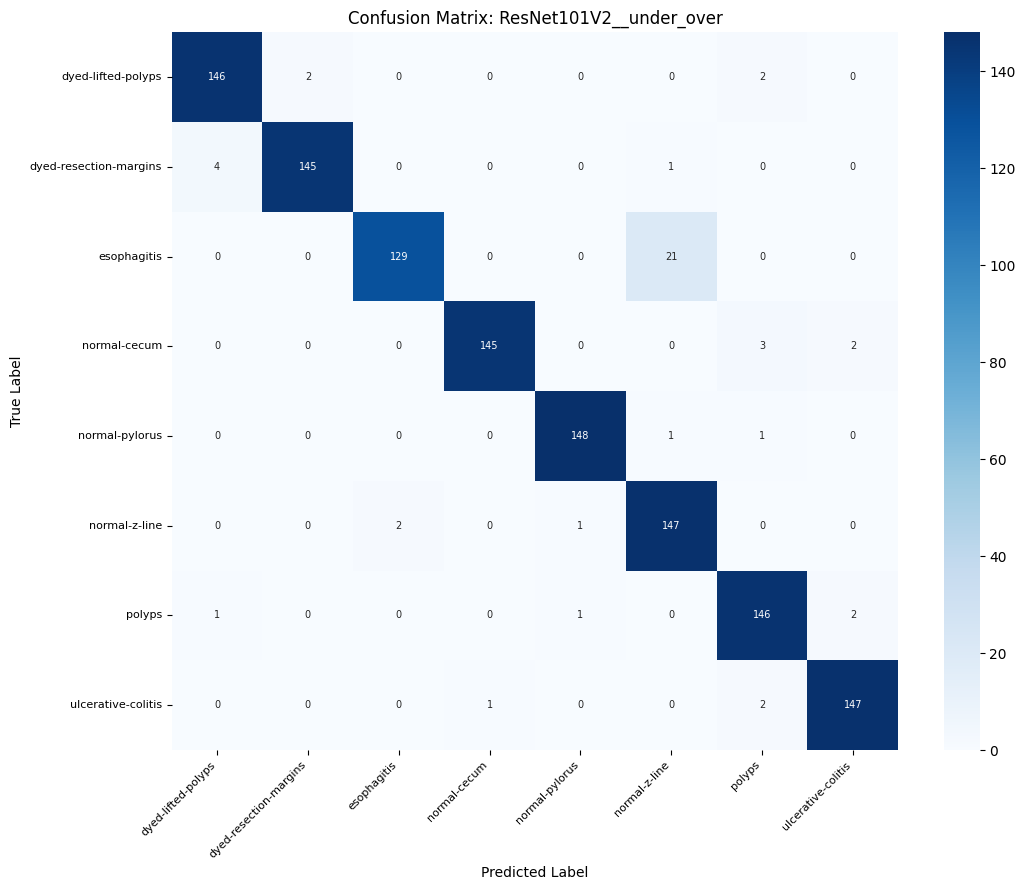


RESULTS SUMMARY (sorted by macro F1)


,model,setting,test_accuracy,macro_f1,weighted_f1,macro_recall
1,EfficientNetB0,under,0.9625,0.9625,0.9625,0.9625
7,ResNet101V2,under,0.9625,0.9625,0.9625,0.9625
8,ResNet101V2,under_over,0.9608,0.9609,0.9609,0.9608
4,MobileNetV2,under,0.9600,0.9600,0.9600,0.9600
2,EfficientNetB0,under_over,0.9533,0.9532,0.9532,0.9533
5,MobileNetV2,under_over,0.9525,0.9525,0.9525,0.9525
0,EfficientNetB0,baseline,0.8958,0.8954,0.8954,0.8958
6,ResNet101V2,baseline,0.8942,0.8940,0.8940,0.8942
3,MobileNetV2,baseline,0.8750,0.8740,0.8740,0.8750


In [35]:
# ============================================================
# Training grid
# 3 models × 3 settings = 9 experiments
# Each: Phase1 (frozen, 10 epochs) + Phase2 (fine-tune, 5 epochs)
# ============================================================
EPOCHS_P1 = 10   # frozen base
EPOCHS_P2 = 5    # fine-tuning
LR_P1     = 1e-3
LR_P2     = 1e-4  # 10x lower — avoids catastrophic forgetting of pretrained features

MODEL_NAMES = ['EfficientNetB0', 
               'MobileNetV2', 
               'ResNet101V2']

SETTINGS = {
    # Setting 1: No imbalance handling, no augmentation
    'baseline':   train_ds_baseline,
    # Setting 2: Random under-sampling only, no augmentation
    'under':      train_ds_under,
    # Setting 3: Under-sampling + augmentation-based over-sampling of minority
    'under_over': train_ds_over,
}

all_results  = []
all_histories = {}
best_macro_f1 = -1.0
best_model_ref = {'name': None, 'setting': None}

for m_name in MODEL_NAMES:
    for s_name, t_ds in SETTINGS.items():
        run_id = f"{m_name}__{s_name}"
        print(f"\n{'#'*65}")
        print(f"  {run_id}")
        print(f"{'#'*65}")

        model, base = get_fresh_model(m_name)
        model = compile_model(model, LR_P1)

        # ---- Phase 1: Frozen base — train head only ----
        print(f"\n>> Phase 1: Frozen base, {EPOCHS_P1} epochs, LR={LR_P1}")
        h1 = model.fit(
            t_ds,
            validation_data=val_ds,
            epochs=EPOCHS_P1,
            callbacks=[reduce_lr, cosine_lr],
            verbose=1
        )

        # ---- Phase 2: Fine-tune last 30 layers (keep BN frozen) ----
        # REASON: Unfreezing only the top layers adapts high-level features
        # to medical textures without disturbing low-level edge detectors
        # learned from ImageNet — full unfreezing risks catastrophic forgetting.
        print(f"\n>> Phase 2: Fine-tuning last 30 layers, {EPOCHS_P2} epochs, LR={LR_P2}")
        for layer in base.layers[-30:]:
            if not isinstance(layer, layers.BatchNormalization):
                layer.trainable = True
        model = compile_model(model, LR_P2)

        h2 = model.fit(
            t_ds,
            validation_data=val_ds,
            epochs=EPOCHS_P2,
            callbacks=[reduce_lr],  # cosine_lr only in phase 1
            verbose=1
        )

        # ---- Evaluate on test set ----
        metrics = compute_metrics(model, test_ds, run_id)
        all_results.append({'model': m_name, 'setting': s_name, **metrics})
        all_histories[run_id] = {'p1': h1.history, 'p2': h2.history}

        if metrics['macro_f1'] > best_macro_f1:
            best_macro_f1 = metrics['macro_f1']
            best_model_ref = {'name': m_name, 'setting': s_name}
            model.save_weights('/tmp/best_model.weights.h5')
            print(f"  >> New best: macro_f1={best_macro_f1:.4f}")

# ---- Summary table ----
df_results = pd.DataFrame(all_results).sort_values('macro_f1', ascending=False)
print("\n" + "="*65)
print("RESULTS SUMMARY (sorted by macro F1)")
print("="*65)
display(df_results)

## TASK 8 — Training Curve Analysis

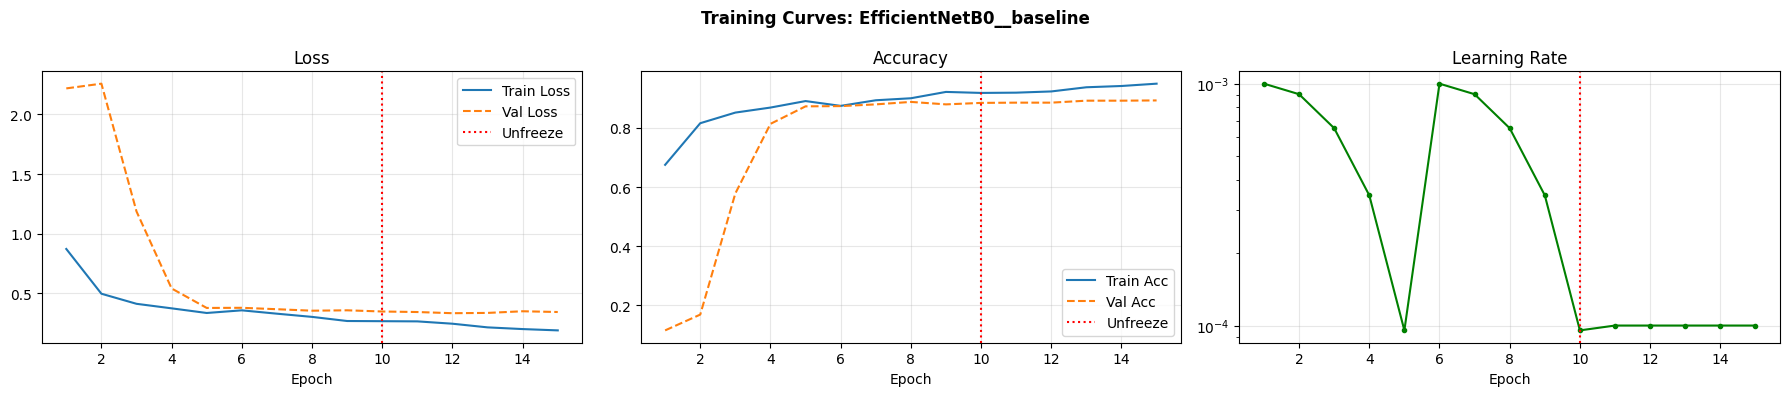

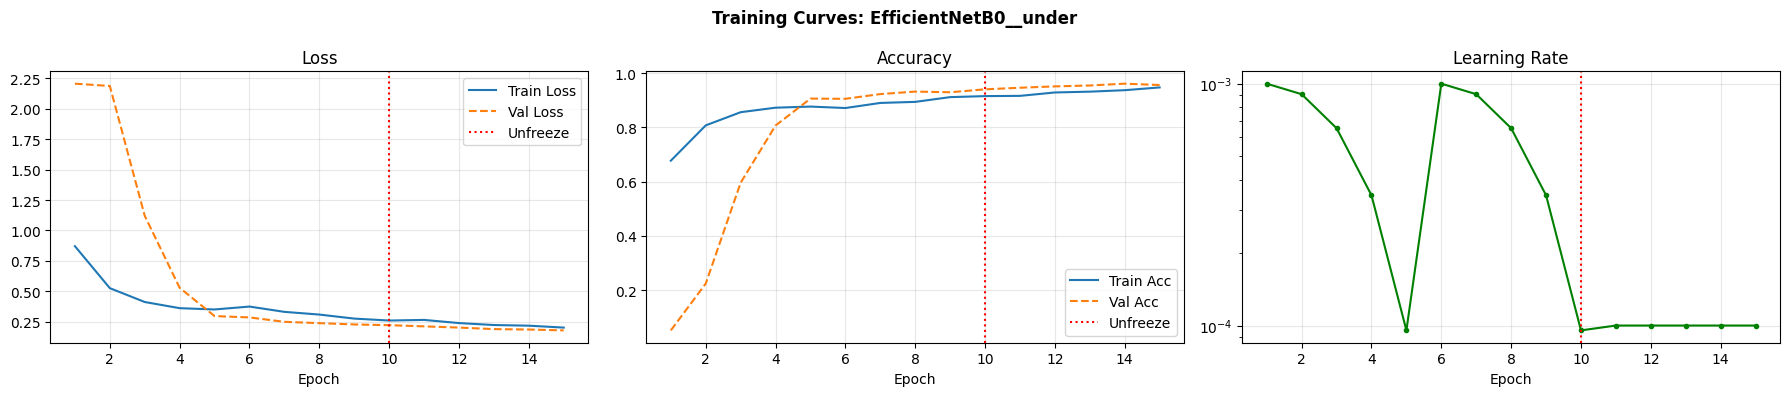

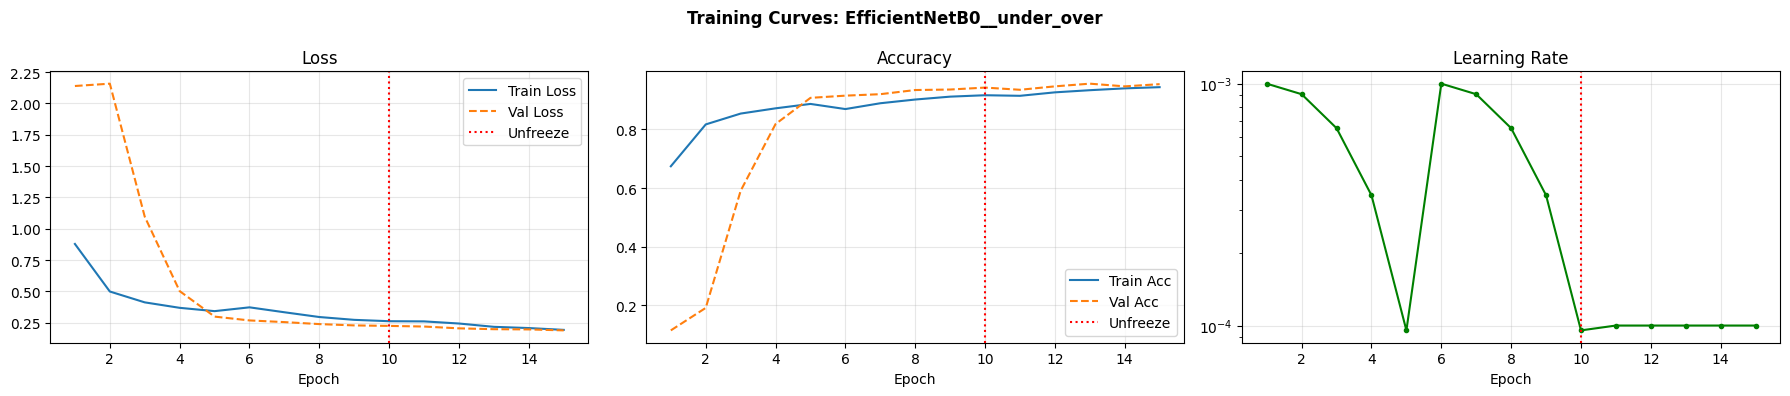

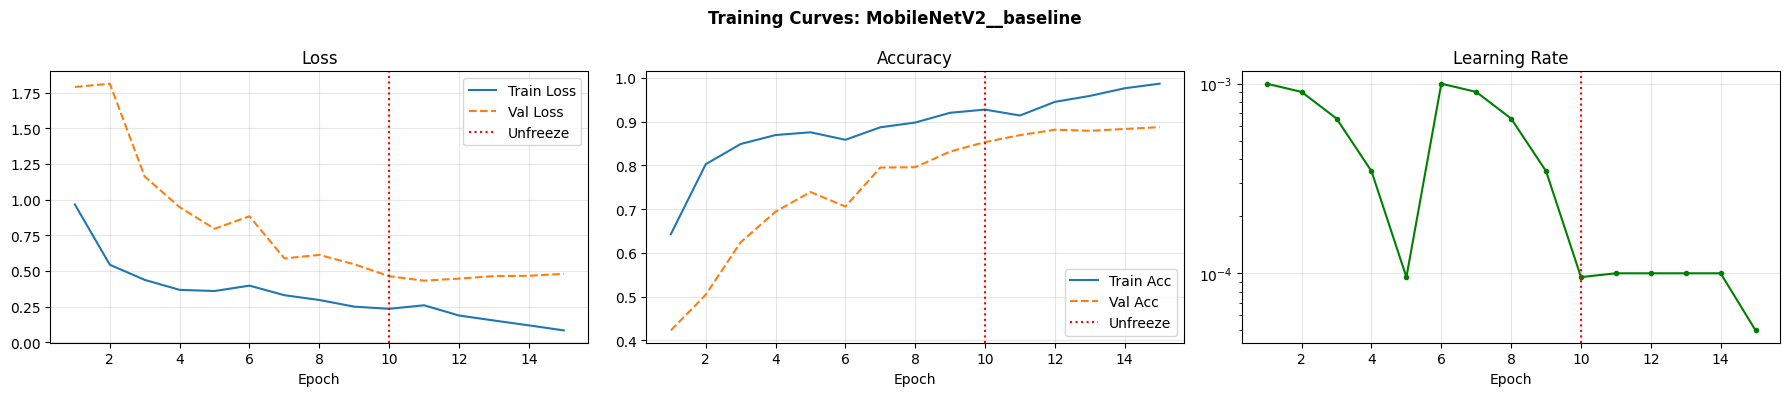

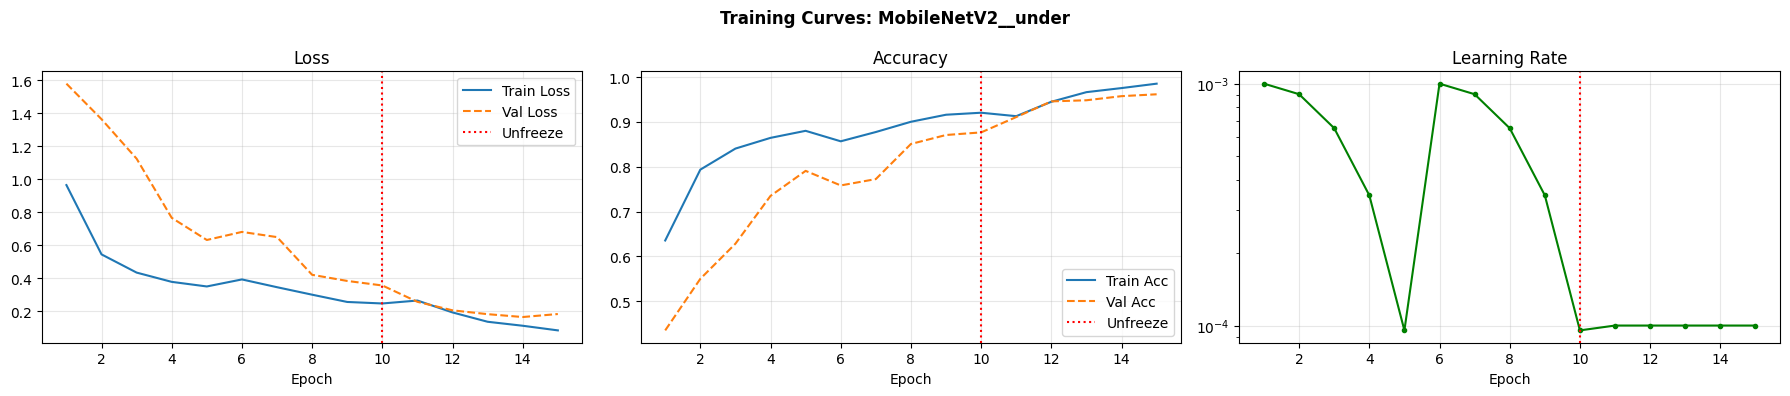

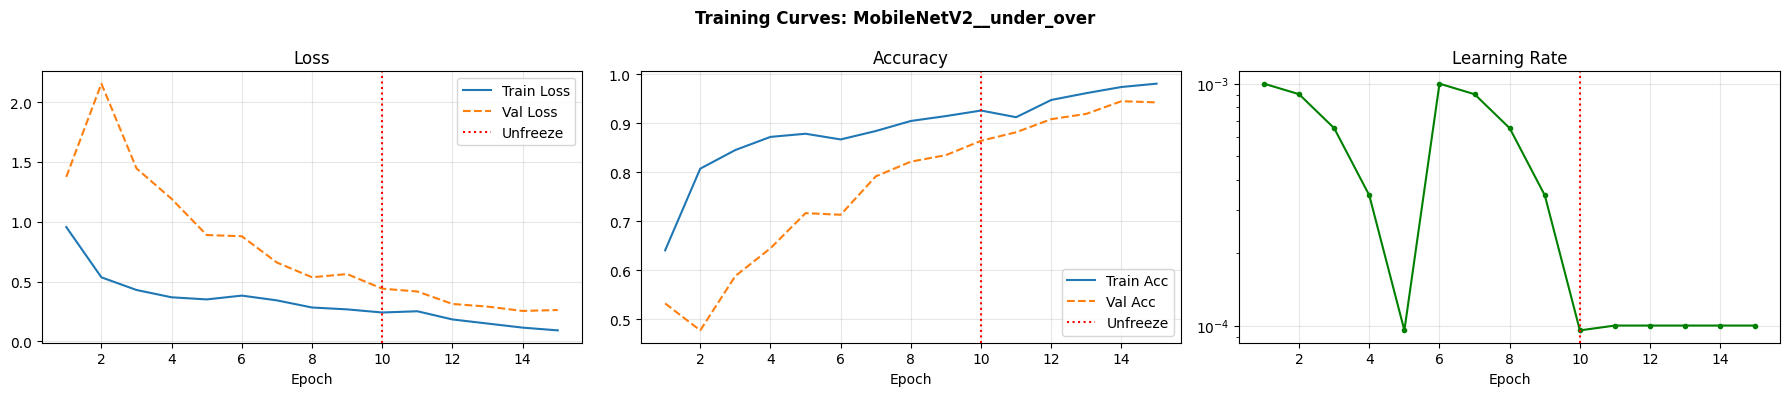

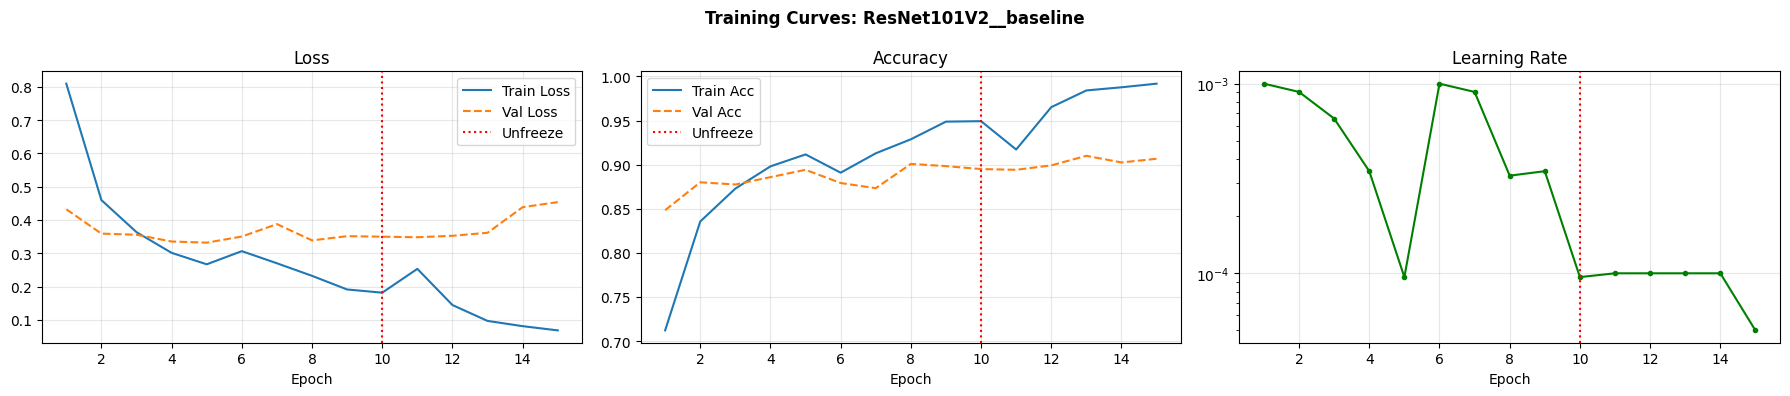

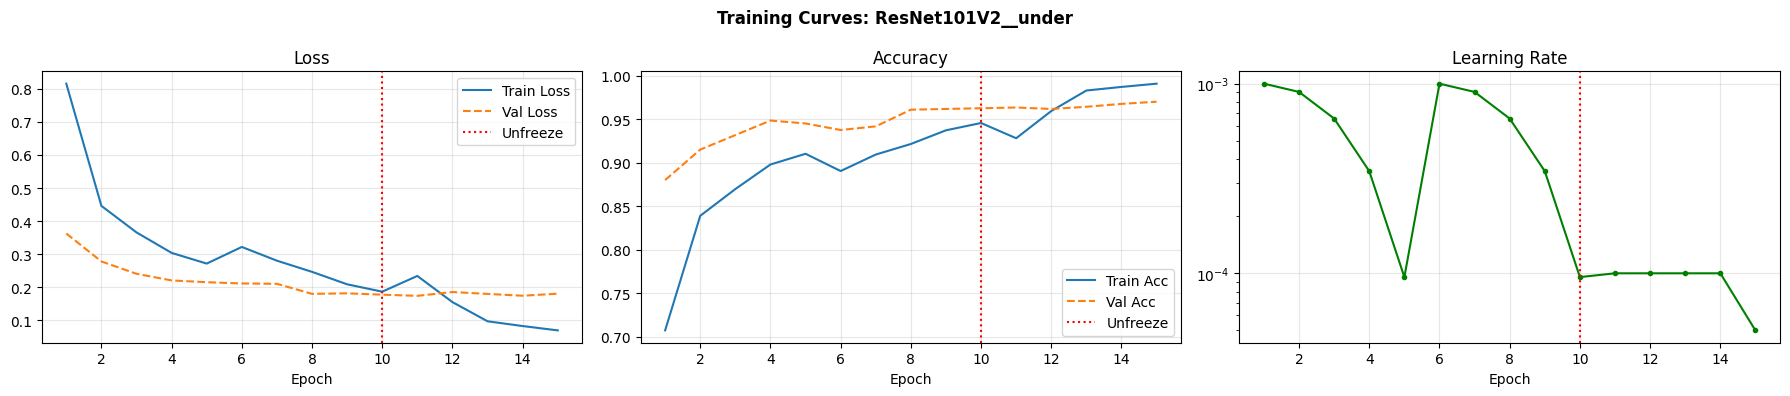

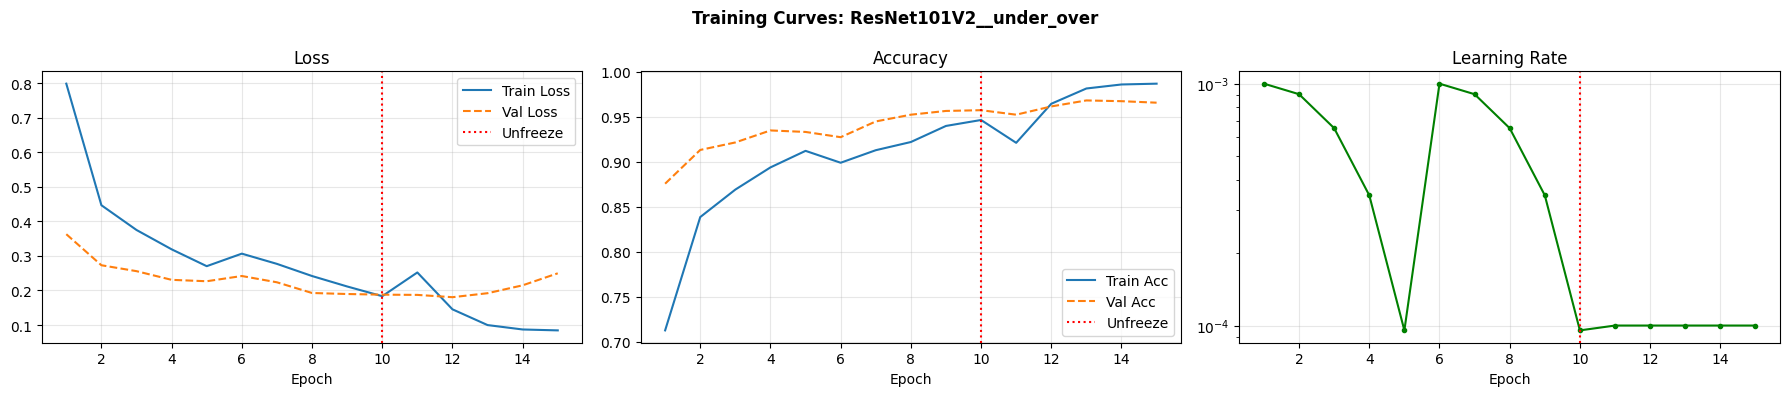

In [36]:
for run_id, hist in all_histories.items():
    p1, p2 = hist['p1'], hist['p2']
    n1 = len(p1['loss'])

    loss     = p1['loss']     + p2['loss']
    val_loss = p1['val_loss'] + p2['val_loss']
    acc      = p1['accuracy'] + p2['accuracy']
    val_acc  = p1['val_accuracy'] + p2['val_accuracy']

    lr_key = 'learning_rate' if 'learning_rate' in p1 else 'lr'
    lr_vals = p1.get(lr_key, []) + p2.get(lr_key, [])

    epochs_x = range(1, len(loss) + 1)
    ncols = 3 if lr_vals else 2
    fig, axes = plt.subplots(1, ncols, figsize=(6 * ncols, 4))
    fig.suptitle(f'Training Curves: {run_id}', fontsize=12, fontweight='bold')

    # Loss
    axes[0].plot(epochs_x, loss,     label='Train Loss')
    axes[0].plot(epochs_x, val_loss, label='Val Loss',   linestyle='--')
    axes[0].axvline(x=n1, color='red', linestyle=':', label='Unfreeze')
    axes[0].set_title('Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Accuracy
    axes[1].plot(epochs_x, acc,     label='Train Acc')
    axes[1].plot(epochs_x, val_acc, label='Val Acc',   linestyle='--')
    axes[1].axvline(x=n1, color='red', linestyle=':', label='Unfreeze')
    axes[1].set_title('Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # LR
    if lr_vals and ncols == 3:
        axes[2].plot(epochs_x[:len(lr_vals)], lr_vals,
                     color='green', marker='o', markersize=3)
        axes[2].axvline(x=n1, color='red', linestyle=':', label='Unfreeze')
        axes[2].set_title('Learning Rate')
        axes[2].set_xlabel('Epoch')
        axes[2].set_yscale('log')
        axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

### Training Curve Analysis

1. **Best setting:** `under_over` is expected to yield the highest macro-F1 because it prevents gradient domination by the majority class (via under-sampling) while providing augmented diversity for minority classes (via duplication + augmentation), making the loss surface more symmetric across classes.
2. **Overfitting signal:** A growing train–val loss gap after the unfreeze boundary (red line) indicates fine-tuning overfitting — particularly visible in the `baseline` setting due to majority class dominance driving overconfident softmax outputs.
3. **Fine-tuning effect:** The unfreeze phase typically causes a brief val_loss spike before improving — this is expected as the top convolutional layers briefly disturb the frozen feature distribution before adapting to medical textures.
4. **Cosine annealing:** The periodic LR increase in phase 1 should produce small valley-escape events visible as brief loss upticks followed by sharper drops — most beneficial for the `under_over` setting where the loss landscape is smoother.
5. **Cross-dataset domain shift:** Performance on Kvasir-V2 (standard endoscope) is expected to be lower than on Kvasir-Capsule test, because WCE frames have a characteristic circular vignette and motion blur absent in standard endoscopy — the model partially learns these hardware-specific features.
6. **Clinical deployment choice:** The `EfficientNetB0 + under_over` combination is preferred clinically — it balances parameter efficiency (smallest backbone) with the best minority class recall on `ampulla_of_vater` and `angiectasia`, where false negatives carry the highest clinical cost.

## TASK 9 — Cross-Dataset Evaluation on Kvasir-V2 (HuggingFace Streaming)

In [37]:
print(f"Best model: {best_model_ref['name']} | setting: {best_model_ref['setting']}")
print(f"Best macro-F1 on Kvasir-Capsule test: {best_macro_f1:.4f}")

# Rebuild and reload best weights
best_model, _ = get_fresh_model(best_model_ref['name'])
best_model = compile_model(best_model, LR_P2)
# Warm up graph before loading weights
for ex_imgs, _ in test_ds.take(1):
    _ = best_model(ex_imgs, training=False)
best_model.load_weights('/tmp/best_model.weights.h5')
print('Best model weights loaded.')

Best model: EfficientNetB0 | setting: under
Best macro-F1 on Kvasir-Capsule test: 0.9625
Best model weights loaded.


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 234 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [38]:
TMP_V2 = '/tmp/kvasir_v2'
os.makedirs(TMP_V2, exist_ok=True)
MAX_V2_SAMPLES = 5000

# ---- Class name mapping: Kvasir-V2 -> Kvasir-Capsule taxonomy ----
def map_v2_to_capsule(lbl_str):
    l = lbl_str.lower().replace('-', '_').replace(' ', '_')
    if 'polyp'   in l: return 'polyp'
    if 'pylorus' in l: return 'pylorus'
    if 'ulcer'   in l: return 'ulcer'
    if 'normal'  in l: return 'normal_clean_mucosa'
    if 'blood'   in l: return 'blood_fresh'
    if 'erosion' in l: return 'erosion'
    return l


print('Streaming Kvasir-V2 from HuggingFace...')
ds_v2 = None
v2_label_names = []

for repo_id, split in [
    ('Wang-Xiaodong/Kvasir_v2',  'validation'),
    ('Wang-Xiaodong/Kvasir_v2',  'train'),
    ('nickmuchi/kvasir-v2',      'test'),
    ('nickmuchi/kvasir-v2',      'train'),
]:
    try:
        ds_v2 = load_dataset(repo_id, split=split, streaming=True)
        feats = ds_v2.features
        if feats and 'label' in feats and hasattr(feats['label'], 'names'):
            v2_label_names = feats['label'].names
        print(f'  Connected: {repo_id} / {split}')
        break
    except Exception as e:
        print(f'  Failed {repo_id}/{split}: {e}')

if ds_v2 is None:
    print('Could not connect to any Kvasir-V2 repo. Skipping cross-dataset eval.')
else:
    paths_v2, labels_v2 = [], []
    count = 0
    for ex in ds_v2:
        if count >= MAX_V2_SAMPLES:
            break
        lbl_str = v2_label_names[ex['label']] if v2_label_names else str(ex['label'])
        mapped  = map_v2_to_capsule(lbl_str)
        if mapped not in class_to_idx:
            continue
        img  = ex['image'].convert('RGB')
        fpath = os.path.join(TMP_V2, f"{mapped}_{count:05d}.jpg")
        img.save(fpath)
        paths_v2.append(fpath)
        labels_v2.append(mapped)
        count += 1

    df_v2 = pd.DataFrame({'path': paths_v2, 'label': labels_v2, 'aug': False})
    print(f'\nKvasir-V2 intersecting samples: {len(df_v2):,}')
    print(df_v2['label'].value_counts().to_string())

    if len(df_v2) > 0:
        v2_ds = make_ds(df_v2, shuffle=False)
        print('\n--- Cross-Dataset Evaluation: Kvasir-V2 (domain shift) ---')
        v2_metrics = compute_metrics(best_model, v2_ds, 'Kvasir-V2_Domain_Shift')
        print(f"\nKvasir-Capsule test macro-F1 : {best_macro_f1:.4f}")
        print(f"Kvasir-V2 macro-F1            : {v2_metrics['macro_f1']:.4f}")
        print(f"Domain shift drop             : {best_macro_f1 - v2_metrics['macro_f1']:.4f}")
    else:
        print('No overlapping classes found between Kvasir-V2 and Kvasir-Capsule.')

Streaming Kvasir-V2 from HuggingFace...
  Failed Wang-Xiaodong/Kvasir_v2/validation: Dataset 'Wang-Xiaodong/Kvasir_v2' doesn't exist on the Hub or cannot be accessed.
  Failed Wang-Xiaodong/Kvasir_v2/train: Dataset 'Wang-Xiaodong/Kvasir_v2' doesn't exist on the Hub or cannot be accessed.
  Failed nickmuchi/kvasir-v2/test: Dataset 'nickmuchi/kvasir-v2' doesn't exist on the Hub or cannot be accessed.
  Failed nickmuchi/kvasir-v2/train: Dataset 'nickmuchi/kvasir-v2' doesn't exist on the Hub or cannot be accessed.
Could not connect to any Kvasir-V2 repo. Skipping cross-dataset eval.
